<a href="https://colab.research.google.com/github/rishoct26/Screenshot-Organizer/blob/main/Screenshot_Organizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 1 — Installs (numpy-safe version)
# ═══════════════════════════════════════════════════

# Only install what Colab doesn't already have
# Do NOT touch numpy, pandas, scikit-learn, matplotlib — Colab's versions work fine

!pip install -q open_clip_torch
!pip install -q transformers==4.41.0
!pip install -q pytesseract==0.3.10
!pip install -q imagehash==4.3.1
!pip install -q gradio==5.0.0

# Tesseract system dependency
!apt-get install -qq tesseract-ocr
!apt-get install -qq tesseract-ocr-all

print("✅ All installs complete — do NOT restart, run Cell 2 directly")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.8/319.8 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

In [ ]:
# ═══════════════════════════════════════════════════
# RECOVERY CELL — Run after any runtime reset
# Restores everything needed to continue
# ═══════════════════════════════════════════════════
import os, json, random, shutil, subprocess, re, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import open_clip
from transformers import BertTokenizer, BertModel
import pytesseract
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report,
                             confusion_matrix, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns
import imagehash
import cv2

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Seeds ─────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# ── Classes ───────────────────────────────────────
CLASSES   = ['social', 'finance', 'education', 'productivity']
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS = {i: c for i, c in enumerate(CLASSES)}

# ── Paths ─────────────────────────────────────────
BASE      = Path('/content/drive/MyDrive/screenshot_organizer_v2')
FILTERED  = BASE / 'filtered'
FINAL     = BASE / 'final'
CKPT_DIR  = BASE / 'checkpoints'
OCR_FILE  = BASE / 'ocr_texts.json'
META_FILE = BASE / 'metadata.csv'
ABLATION  = BASE / 'ablation_results.json'
LOCAL     = Path('/content/scratch')
LOCAL_UZK = LOCAL / 'uzairkhan45'
LOCAL_CKPT = Path('/content/gated_fusion_local.pt')

# ── Transforms ────────────────────────────────────
CLIP_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275,  0.40821073],
        std= [0.26862954, 0.26130258, 0.27577711])
])
RESNET_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225])
])

# ── Load OCR ──────────────────────────────────────
with open(OCR_FILE) as f:
    ocr_data = json.load(f)
print(f"OCR entries: {len(ocr_data)}")

# ── BERT tokenizer ────────────────────────────────
print("Loading multilingual BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained(
    'bert-base-multilingual-cased')

# ── Dataset ───────────────────────────────────────
class ScreenshotDataset(Dataset):
    def __init__(self, split, transform=None):
        self.transform = transform or CLIP_TRANSFORM
        self.samples   = []
        for cls in CLASSES:
            cls_dir = FINAL / split / cls
            imgs    = list(cls_dir.glob('*.jpg')) + \
                      list(cls_dir.glob('*.png'))
            for img_path in imgs:
                info    = ocr_data.get(img_path.name, {})
                text    = info.get('text', 'no text detected')
                quality = info.get('quality', 'none')
                self.samples.append({
                    'path': img_path, 'label': CLASS2IDX[cls],
                    'class': cls, 'text': text, 'quality': quality
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = Image.open(s['path']).convert('RGB')
        img = self.transform(img)
        return img, s['label'], s['text'], s['quality']

# ── Collate ───────────────────────────────────────
def collate_fn(batch):
    imgs, labels, texts, qualities = zip(*batch)
    imgs      = torch.stack(imgs)
    labels    = torch.tensor(labels, dtype=torch.long)
    tokens    = bert_tokenizer(
        list(texts), padding=True, truncation=True,
        max_length=128, return_tensors='pt')
    ocr_flags = torch.tensor(
        [0 if q == 'none' else 1 for q in qualities],
        dtype=torch.float)
    return imgs, labels, tokens, ocr_flags

# ── Dataloaders ───────────────────────────────────
BATCH_SIZE    = 32
train_dataset = ScreenshotDataset('train')
val_dataset   = ScreenshotDataset('val')
test_dataset  = ScreenshotDataset('test')
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  collate_fn=collate_fn,
                           num_workers=2, pin_memory=False)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn,
                           num_workers=2, pin_memory=False)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn,
                           num_workers=2, pin_memory=False)

# ── Model definitions ─────────────────────────────
NUM_CLASSES = 4

class ResNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet50(weights='IMAGENET1K_V1')
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.backbone.fc.in_features, NUM_CLASSES))
    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        return self.backbone(imgs)

class BERTOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-multilingual-cased')
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(768, 256),
            nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, NUM_CLASSES))
    def forward(self, imgs=None, labels=None, tokens=None, ocr_flags=None):
        return self.classifier(
            self.bert(**tokens).last_hidden_state[:,0,:].float())

class CLIPOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai')
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(512, 256),
            nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, NUM_CLASSES))
    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        return self.classifier(self.clip.encode_image(imgs).float())

class ConcatFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai')
        self.bert       = BertModel.from_pretrained('bert-base-multilingual-cased')
        self.clip_proj  = nn.Linear(512, 256)
        self.bert_proj  = nn.Linear(768, 256)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, NUM_CLASSES))
    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        c = torch.relu(self.clip_proj(
            self.clip.encode_image(imgs).float()))
        b = torch.relu(self.bert_proj(
            self.bert(**tokens).last_hidden_state[:,0,:].float()))
        return self.classifier(torch.cat([c, b], dim=1))

class GatedFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.clip, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai')
        self.bert       = BertModel.from_pretrained('bert-base-multilingual-cased')
        self.clip_proj  = nn.Linear(512, 256)
        self.bert_proj  = nn.Linear(768, 256)
        self.gate       = nn.Sequential(
            nn.Linear(512, 256), nn.Sigmoid())
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128, NUM_CLASSES))
    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        c    = torch.relu(self.clip_proj(
            self.clip.encode_image(imgs).float()))
        b    = torch.relu(self.bert_proj(
            self.bert(**tokens).last_hidden_state[:,0,:].float()))
        gate = self.gate(torch.cat([c, b], dim=1))
        return self.classifier(gate * c + (1 - gate) * b)

# ── Load checkpoint state ─────────────────────────
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt_state = json.load(f)

with open(ABLATION) as f:
    ablation = json.load(f)

print(f"\n✅ Recovery complete")
print(f"   Train: {len(train_dataset)}  "
      f"Val: {len(val_dataset)}  Test: {len(test_dataset)}")
print(f"   Models trained: {list(ablation.keys())}")
print(f"   Device: {device}")
print(f"\n   Ablation results so far:")
for model_name, results in ablation.items():
    print(f"   {model_name:<20}: val={results.get('val_acc','?')}%")

Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
OCR entries: 2400
Loading multilingual BERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]


✅ Recovery complete
   Train: 1680  Val: 360  Test: 360
   Models trained: ['tfidf_lr', 'resnet50', 'clip_only', 'bert_only', 'concat_fusion', 'gated_fusion']
   Device: cuda

   Ablation results so far:
   tfidf_lr            : val=46.11%
   resnet50            : val=39.17%
   clip_only           : val=68.33%
   bert_only           : val=47.22%
   concat_fusion       : val=59.72%
   gated_fusion        : val=66.67%


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 2 — Imports + Seeds + Drive Mount
# ═══════════════════════════════════════════════════
import os, json, random, shutil, subprocess
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# CLIP
import open_clip

# BERT
from transformers import BertTokenizer, BertModel

# OCR
import pytesseract

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Dedup
import imagehash

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Reproducibility ───────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {device}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# ── Class definitions ─────────────────────────────
CLASSES   = ['social', 'finance', 'education', 'productivity']
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS = {i: c for i, c in enumerate(CLASSES)}

# ── Paths — all raw data stays LOCAL, only filtered/final go to Drive ──
BASE      = Path('/content/drive/MyDrive/screenshot_organizer_v2')
FILTERED  = BASE / 'filtered'
FINAL     = BASE / 'final'
CKPT_DIR  = BASE / 'checkpoints'
OCR_FILE  = BASE / 'ocr_texts.json'
META_FILE = BASE / 'metadata.csv'
ABLATION  = BASE / 'ablation_results.json'

LOCAL     = Path('/content/scratch')   # raw downloads — never touches Drive
LOCAL_UZK = LOCAL / 'uzairkhan45'

print(f"\nDrive base : {BASE}")
print(f"Local scratch: {LOCAL}")
print("✅ Cell 2 complete")

Mounted at /content/drive
Device  : cpu
GPU     : None

Drive base : /content/drive/MyDrive/screenshot_organizer_v2
Local scratch: /content/scratch
✅ Cell 2 complete


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 3 — Create Folder Structure
# Safe to re-run — never overwrites existing data
# ═══════════════════════════════════════════════════

folders = [
    # Drive folders (persist across sessions)
    FILTERED / 'social',
    FILTERED / 'finance',
    FILTERED / 'education',
    FILTERED / 'productivity',
    FINAL / 'train' / 'social',
    FINAL / 'train' / 'finance',
    FINAL / 'train' / 'education',
    FINAL / 'train' / 'productivity',
    FINAL / 'val' / 'social',
    FINAL / 'val' / 'finance',
    FINAL / 'val' / 'education',
    FINAL / 'val' / 'productivity',
    FINAL / 'test' / 'social',
    FINAL / 'test' / 'finance',
    FINAL / 'test' / 'education',
    FINAL / 'test' / 'productivity',
    CKPT_DIR,
    # Local scratch (raw downloads — disappears on reset, that's fine)
    LOCAL,
    LOCAL_UZK,
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ Folder structure created:")
for folder in sorted(folders):
    try:
        count = len(list(folder.iterdir()))
    except:
        count = 0
    location = "💾 Drive" if str(folder).startswith('/content/drive') else "⚡ Local"
    print(f"  {location}  {folder.name}/  ({count} files)")

# Save a dataset checkpoint file so we can recover state after T4 reset
import json
checkpoint = {
    "folders_created": True,
    "classes": CLASSES,
    "filtered_counts": {c: 0 for c in CLASSES},
    "final_counts": {"train": 0, "val": 0, "test": 0},
    "ocr_done": False,
    "models_trained": []
}
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(checkpoint, f, indent=2)

print("\n✅ dataset_checkpoint.json saved to Drive")

✅ Folder structure created:
  💾 Drive  checkpoints/  (0 files)
  💾 Drive  education/  (0 files)
  💾 Drive  finance/  (0 files)
  💾 Drive  productivity/  (0 files)
  💾 Drive  social/  (0 files)
  💾 Drive  education/  (0 files)
  💾 Drive  finance/  (0 files)
  💾 Drive  productivity/  (0 files)
  💾 Drive  social/  (0 files)
  💾 Drive  education/  (0 files)
  💾 Drive  finance/  (0 files)
  💾 Drive  productivity/  (0 files)
  💾 Drive  social/  (0 files)
  💾 Drive  education/  (0 files)
  💾 Drive  finance/  (0 files)
  💾 Drive  productivity/  (0 files)
  💾 Drive  social/  (0 files)
  ⚡ Local  scratch/  (1 files)
  ⚡ Local  uzairkhan45/  (0 files)

✅ dataset_checkpoint.json saved to Drive


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 4 — Upload uzairkhan45 dataset from your computer
# ═══════════════════════════════════════════════════
from google.colab import files
import zipfile

print("📤 Select your uzairkhan45 zip file to upload...")
print("   (This may take a few minutes depending on file size)")
uploaded = files.upload()

# Get the uploaded filename
zip_name = list(uploaded.keys())[0]
zip_path = Path('/content') / zip_name
print(f"\n✅ Uploaded: {zip_name} ({zip_path.stat().st_size/1e6:.1f} MB)")

# Extract to local scratch
print(f"\n📦 Extracting to {LOCAL_UZK}...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(LOCAL_UZK)

# See what we got
print("\n📂 Contents after extraction:")
for item in sorted(LOCAL_UZK.iterdir()):
    if item.is_dir():
        imgs = list(item.rglob('*.jpg')) + list(item.rglob('*.png'))
        print(f"  {item.name}/  →  {len(imgs)} images")
    else:
        print(f"  {item.name}  ({item.stat().st_size/1e6:.1f} MB)")

# Count total
all_imgs = list(LOCAL_UZK.rglob('*.jpg')) + list(LOCAL_UZK.rglob('*.png'))
print(f"\nTotal images: {len(all_imgs)}")

📤 Select your uzairkhan45 zip file to upload...
   (This may take a few minutes depending on file size)


Saving uzairkhan45.zip to uzairkhan45.zip

✅ Uploaded: uzairkhan45.zip (282.3 MB)

📦 Extracting to /content/scratch/uzairkhan45...

📂 Contents after extraction:
  Categorized_Andriod_Apps_Images/  →  11999 images

Total images: 11999


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 5 — Explore uzairkhan45 structure
# ═══════════════════════════════════════════════════

uzk_root = LOCAL_UZK / 'Categorized_Andriod_Apps_Images'

print("📂 uzairkhan45 categories:")
categories = sorted([d for d in uzk_root.iterdir() if d.is_dir()])
for cat in categories:
    imgs = list(cat.rglob('*.jpg')) + list(cat.rglob('*.png'))
    print(f"  {cat.name:<30} →  {len(imgs):>4} images")

print(f"\nTotal categories: {len(categories)}")
print(f"Total images: {sum(len(list(c.rglob('*.jpg'))+list(c.rglob('*.png'))) for c in categories)}")

📂 uzairkhan45 categories:
  BUSINESS                       →  1200 images
  EDUCATION                      →  1199 images
  ENTERTAINMENT                  →  1200 images
  GAME                           →  1200 images
  MUSIC                          →  1200 images
  NEWS                           →  1200 images
  PHOTOGRAPHY                    →  1200 images
  SOCIAL                         →  1200 images
  SPORTS                         →  1200 images
  TOOLS                          →  1200 images

Total categories: 10
Total images: 11999


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 6 — Filter + Sample uzairkhan45 → filtered/
# Maps categories to our 4 classes, samples 400 each
# Saves directly to Drive filtered/ folders
# ═══════════════════════════════════════════════════

# Class mapping
UZK_MAP = {
    'SOCIAL':        'social',
    'ENTERTAINMENT': 'social',
    'BUSINESS':      'finance',
    'TOOLS':         'productivity',
    'EDUCATION':     'education',
    'NEWS':          'education',
}

TARGET_PER_CLASS = 400
uzk_root = LOCAL_UZK / 'Categorized_Andriod_Apps_Images'

# Collect all images per target class
class_pool = {c: [] for c in CLASSES}
for cat_name, class_name in UZK_MAP.items():
    cat_path = uzk_root / cat_name
    if cat_path.exists():
        imgs = list(cat_path.rglob('*.jpg')) + list(cat_path.rglob('*.png'))
        class_pool[class_name].extend(imgs)
        print(f"  {cat_name:<20} → {class_name:<15} ({len(imgs)} images)")

print("\n📊 Pool sizes before sampling:")
for cls, imgs in class_pool.items():
    print(f"  {cls:<15}: {len(imgs)} images")

# Sample and copy to Drive filtered/
print("\n📋 Sampling and copying to Drive...")
metadata_rows = []

for cls in CLASSES:
    pool = class_pool[cls]
    random.shuffle(pool)
    selected = pool[:TARGET_PER_CLASS]
    dest_dir = FILTERED / cls

    # Check how many already exist
    existing = list(dest_dir.glob('*.jpg')) + list(dest_dir.glob('*.png'))
    if len(existing) >= TARGET_PER_CLASS:
        print(f"  ✅ {cls}: already has {len(existing)} images — skipping")
        continue

    copied = 0
    for img_path in tqdm(selected, desc=f"  {cls}", leave=False):
        # Rename with class prefix for easy identification
        new_name = f"uzk_{cls}_{copied:04d}{img_path.suffix}"
        dest = dest_dir / new_name
        shutil.copy2(img_path, dest)
        metadata_rows.append({
            'filename': new_name,
            'class': cls,
            'source': 'uzairkhan45',
            'original_path': str(img_path.name)
        })
        copied += 1

    print(f"  ✅ {cls}: copied {copied} images to Drive")

# Save metadata
df_meta = pd.DataFrame(metadata_rows)
df_meta.to_csv(META_FILE, index=False)
print(f"\n✅ metadata.csv saved: {len(df_meta)} rows")

# Final count
print("\n📊 filtered/ counts on Drive:")
for cls in CLASSES:
    count = len(list((FILTERED/cls).glob('*')))
    print(f"  {cls:<15}: {count} images")

  SOCIAL               → social          (1200 images)
  ENTERTAINMENT        → social          (1200 images)
  BUSINESS             → finance         (1200 images)
  TOOLS                → productivity    (1200 images)
  EDUCATION            → education       (1199 images)
  NEWS                 → education       (1200 images)

📊 Pool sizes before sampling:
  social         : 2400 images
  finance        : 1200 images
  education      : 2399 images
  productivity   : 1200 images

📋 Sampling and copying to Drive...


  ✅ social: copied 400 images to Drive


  ✅ finance: copied 400 images to Drive


  ✅ education: copied 400 images to Drive


  ✅ productivity: copied 400 images to Drive

✅ metadata.csv saved: 1600 rows

📊 filtered/ counts on Drive:
  social         : 400 images
  finance        : 400 images
  education      : 400 images
  productivity   : 400 images


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 7 — Deduplication Check
# Uses perceptual hashing to find duplicate images
# across all classes before splitting
# ═══════════════════════════════════════════════════

print("🔍 Running deduplication check...")
print("   Using perceptual hash (phash) — catches near-duplicates too\n")

all_hashes = {}   # hash → file path
duplicates  = []

for cls in CLASSES:
    cls_dir = FILTERED / cls
    imgs    = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))

    for img_path in tqdm(imgs, desc=f"  Hashing {cls}", leave=False):
        try:
            h = str(imagehash.phash(Image.open(img_path)))
            if h in all_hashes:
                duplicates.append({
                    'file':       str(img_path.name),
                    'class':      cls,
                    'duplicate_of': str(all_hashes[h])
                })
            else:
                all_hashes[h] = img_path
        except Exception as e:
            print(f"  ⚠️ Could not hash {img_path.name}: {e}")

print(f"\n📊 Deduplication results:")
print(f"  Total images checked : 1600")
print(f"  Unique hashes        : {len(all_hashes)}")
print(f"  Duplicates found     : {len(duplicates)}")

if duplicates:
    print(f"\n  Removing {len(duplicates)} duplicates...")
    for dup in duplicates:
        dup_path = FILTERED / dup['class'] / dup['file']
        if dup_path.exists():
            dup_path.unlink()
            print(f"  🗑️  Removed: {dup['file']} ({dup['class']})")

    # Report final counts
    print(f"\n📊 Counts after dedup:")
    for cls in CLASSES:
        count = len(list((FILTERED/cls).glob('*')))
        print(f"  {cls:<15}: {count} images")
else:
    print("  ✅ No duplicates found — dataset is clean")

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['dedup_done'] = True
ckpt['filtered_counts'] = {
    cls: len(list((FILTERED/cls).glob('*'))) for cls in CLASSES
}
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print("\n✅ Checkpoint updated")

🔍 Running deduplication check...
   Using perceptual hash (phash) — catches near-duplicates too




📊 Deduplication results:
  Total images checked : 1600
  Unique hashes        : 1440
  Duplicates found     : 160

  Removing 160 duplicates...
  🗑️  Removed: uzk_social_0014.jpg (social)
  🗑️  Removed: uzk_social_0072.jpg (social)
  🗑️  Removed: uzk_social_0129.jpg (social)
  🗑️  Removed: uzk_social_0131.jpg (social)
  🗑️  Removed: uzk_social_0133.jpg (social)
  🗑️  Removed: uzk_social_0155.jpg (social)
  🗑️  Removed: uzk_social_0160.jpg (social)
  🗑️  Removed: uzk_social_0165.jpg (social)
  🗑️  Removed: uzk_social_0192.jpg (social)
  🗑️  Removed: uzk_social_0207.jpg (social)
  🗑️  Removed: uzk_social_0215.jpg (social)
  🗑️  Removed: uzk_social_0220.jpg (social)
  🗑️  Removed: uzk_social_0224.jpg (social)
  🗑️  Removed: uzk_social_0231.jpg (social)
  🗑️  Removed: uzk_social_0234.jpg (social)
  🗑️  Removed: uzk_social_0245.jpg (social)
  🗑️  Removed: uzk_social_0253.jpg (social)
  🗑️  Removed: uzk_social_0257.jpg (social)
  🗑️  Removed: uzk_social_0270.jpg (social)
  🗑️  Removed: uzk_

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 8 — Top up filtered/ back to 400 per class
# Uses remaining uzairkhan45 pool images
# ═══════════════════════════════════════════════════

TARGET = 400
uzk_root = LOCAL_UZK / 'Categorized_Andriod_Apps_Images'

# Rebuild pool of UNUSED images (not already copied to filtered/)
print("🔄 Building remaining pool from uzairkhan45...")

# Get already-used filenames from metadata
df_meta = pd.read_csv(META_FILE)
used_originals = set(df_meta['original_path'].tolist())

# Rebuild class pool from unused images
class_pool = {c: [] for c in CLASSES}
for cat_name, class_name in UZK_MAP.items():
    cat_path = uzk_root / cat_name
    if cat_path.exists():
        imgs = list(cat_path.rglob('*.jpg')) + list(cat_path.rglob('*.png'))
        for img in imgs:
            if img.name not in used_originals:
                class_pool[class_name].append(img)

print("📊 Unused pool sizes:")
for cls, pool in class_pool.items():
    print(f"  {cls:<15}: {len(pool)} unused images available")

# Top up each class
print("\n📋 Topping up to 400 per class...")
new_meta_rows = []

for cls in CLASSES:
    dest_dir   = FILTERED / cls
    current    = list(dest_dir.glob('*.jpg')) + list(dest_dir.glob('*.png'))
    needed     = TARGET - len(current)

    if needed <= 0:
        print(f"  ✅ {cls}: already at {len(current)} — no top up needed")
        continue

    pool = class_pool[cls]
    random.shuffle(pool)
    additions = pool[:needed]

    if len(additions) < needed:
        print(f"  ⚠️ {cls}: only {len(additions)} unused images available, needed {needed}")

    # Get current max index for naming
    existing_nums = [int(f.stem.split('_')[-1]) for f in dest_dir.glob('uzk_*.jpg')
                     if f.stem.split('_')[-1].isdigit()]
    start_idx = max(existing_nums) + 1 if existing_nums else 400

    copied = 0
    for img_path in additions:
        new_name = f"uzk_{cls}_{start_idx + copied:04d}{img_path.suffix}"
        dest = dest_dir / new_name
        shutil.copy2(img_path, dest)
        new_meta_rows.append({
            'filename':      new_name,
            'class':         cls,
            'source':        'uzairkhan45',
            'original_path': img_path.name
        })
        copied += 1

    print(f"  ✅ {cls}: added {copied} images → now {len(current)+copied}")

# Update metadata
if new_meta_rows:
    df_new  = pd.DataFrame(new_meta_rows)
    df_meta = pd.concat([df_meta, df_new], ignore_index=True)
    df_meta.to_csv(META_FILE, index=False)
    print(f"\n✅ metadata.csv updated: {len(df_meta)} total rows")

# Final counts
print("\n📊 Final filtered/ counts:")
for cls in CLASSES:
    count = len(list((FILTERED/cls).glob('*')))
    print(f"  {cls:<15}: {count} images")

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['filtered_counts'] = {
    cls: len(list((FILTERED/cls).glob('*'))) for cls in CLASSES
}
ckpt['topup_done'] = True
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print("✅ Checkpoint updated")

🔄 Building remaining pool from uzairkhan45...
📊 Unused pool sizes:
  social         : 2000 unused images available
  finance        : 800 unused images available
  education      : 1999 unused images available
  productivity   : 800 unused images available

📋 Topping up to 400 per class...
  ✅ social: added 36 images → now 400
  ✅ finance: added 38 images → now 400
  ✅ education: added 32 images → now 400
  ✅ productivity: added 54 images → now 400

✅ metadata.csv updated: 1760 total rows

📊 Final filtered/ counts:
  social         : 400 images
  finance        : 400 images
  education      : 400 images
  productivity   : 400 images
✅ Checkpoint updated


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 9 — OCR Extraction + Quality Gate
# Extracts text from all 1600 images using pytesseract
# Flags low-quality OCR instead of discarding
# ═══════════════════════════════════════════════════

import pytesseract
import re

def extract_ocr(img_path):
    """Extract OCR text with quality assessment."""
    try:
        img = Image.open(img_path).convert('RGB')
        # Resize if too large — speeds up OCR significantly
        if max(img.size) > 1024:
            img.thumbnail((1024, 1024), Image.LANCZOS)
        text = pytesseract.image_to_string(img, timeout=10)
        # Clean text
        text = re.sub(r'\s+', ' ', text).strip()
        # Count meaningful words (length > 2, alphanumeric)
        words = [w for w in text.split() if len(w) > 2 and w.isalnum()]
        quality = 'high' if len(words) >= 5 else \
                  'low'  if len(words) >= 2 else 'none'
        return text if len(words) >= 2 else 'no text detected', quality
    except Exception as e:
        return 'no text detected', 'none'

# Check if OCR already done
if OCR_FILE.exists():
    with open(OCR_FILE) as f:
        ocr_data = json.load(f)
    print(f"✅ OCR already exists: {len(ocr_data)} entries — skipping")
else:
    ocr_data    = {}
    quality_log = {'high': 0, 'low': 0, 'none': 0}

    for cls in CLASSES:
        cls_dir = FILTERED / cls
        imgs    = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
        print(f"\n🔤 OCR processing {cls} ({len(imgs)} images)...")

        cls_quality = {'high': 0, 'low': 0, 'none': 0}
        for img_path in tqdm(imgs, desc=f"  {cls}"):
            text, quality = extract_ocr(img_path)
            ocr_data[img_path.name] = {
                'text':    text,
                'quality': quality,
                'class':   cls
            }
            cls_quality[quality] += 1
            quality_log[quality] += 1

        print(f"  Quality — high: {cls_quality['high']}  "
              f"low: {cls_quality['low']}  "
              f"none: {cls_quality['none']}")

    # Save to Drive
    with open(OCR_FILE, 'w') as f:
        json.dump(ocr_data, f)
    print(f"\n✅ OCR saved to Drive: {len(ocr_data)} entries")

    # Summary
    print(f"\n📊 Overall OCR Quality:")
    print(f"  High confidence (5+ words) : {quality_log['high']}")
    print(f"  Low confidence  (2-4 words): {quality_log['low']}")
    print(f"  No text detected (0-1 words): {quality_log['none']}")
    print(f"  Fallback rate: {(quality_log['low']+quality_log['none'])/16:.1f}%")

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['ocr_done'] = True
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print("\n✅ Checkpoint updated")


🔤 OCR processing social (400 images)...


  social: 100%|██████████| 400/400 [02:37<00:00,  2.54it/s]


  Quality — high: 102  low: 67  none: 231

🔤 OCR processing finance (400 images)...


  finance: 100%|██████████| 400/400 [02:43<00:00,  2.45it/s]


  Quality — high: 143  low: 67  none: 190

🔤 OCR processing education (400 images)...


  education: 100%|██████████| 400/400 [02:30<00:00,  2.65it/s]


  Quality — high: 109  low: 58  none: 233

🔤 OCR processing productivity (400 images)...


  productivity: 100%|██████████| 400/400 [02:37<00:00,  2.55it/s]

  Quality — high: 126  low: 62  none: 212

✅ OCR saved to Drive: 1600 entries

📊 Overall OCR Quality:
  High confidence (5+ words) : 480
  Low confidence  (2-4 words): 254
  No text detected (0-1 words): 866
  Fallback rate: 70.0%

✅ Checkpoint updated


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 10 — Train/Val/Test Split
# 70/15/15 split, stratified per class
# Copies from filtered/ → final/train|val|test/
# ═══════════════════════════════════════════════════

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

print("📋 Creating train/val/test split...")
print(f"   Ratios: {int(TRAIN_RATIO*100)}/{int(VAL_RATIO*100)}/{int(TEST_RATIO*100)}\n")

split_counts = {'train': {}, 'val': {}, 'test': {}}

for cls in CLASSES:
    src_dir = FILTERED / cls
    imgs    = list(src_dir.glob('*.jpg')) + list(src_dir.glob('*.png'))
    random.shuffle(imgs)

    n       = len(imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        'train': imgs[:n_train],
        'val':   imgs[n_train:n_train + n_val],
        'test':  imgs[n_train + n_val:]
    }

    for split_name, split_imgs in splits.items():
        dest_dir = FINAL / split_name / cls
        # Check if already populated
        existing = list(dest_dir.glob('*'))
        if len(existing) >= len(split_imgs):
            print(f"  ✅ {split_name}/{cls}: already exists ({len(existing)} files) — skipping")
            split_counts[split_name][cls] = len(existing)
            continue

        for img_path in split_imgs:
            shutil.copy2(img_path, dest_dir / img_path.name)

        split_counts[split_name][cls] = len(split_imgs)

    print(f"  {cls:<15}: train={splits['train'].__len__()}  "
          f"val={splits['val'].__len__()}  "
          f"test={splits['test'].__len__()}")

# Summary table
print(f"\n📊 Split summary:")
print(f"  {'Class':<15} {'Train':>6} {'Val':>6} {'Test':>6} {'Total':>6}")
print(f"  {'-'*45}")
for cls in CLASSES:
    tr = split_counts['train'].get(cls, 0)
    vl = split_counts['val'].get(cls, 0)
    te = split_counts['test'].get(cls, 0)
    print(f"  {cls:<15} {tr:>6} {vl:>6} {te:>6} {tr+vl+te:>6}")

total_train = sum(split_counts['train'].values())
total_val   = sum(split_counts['val'].values())
total_test  = sum(split_counts['test'].values())
print(f"  {'TOTAL':<15} {total_train:>6} {total_val:>6} {total_test:>6} {total_train+total_val+total_test:>6}")

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['split_done']    = True
ckpt['final_counts']  = {
    'train': total_train, 'val': total_val, 'test': total_test
}
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print("\n✅ Checkpoint updated")

📋 Creating train/val/test split...
   Ratios: 70/15/15

  social         : train=280  val=60  test=60
  finance        : train=280  val=60  test=60
  education      : train=280  val=60  test=60
  productivity   : train=280  val=60  test=60

📊 Split summary:
  Class            Train    Val   Test  Total
  ---------------------------------------------
  social             280     60     60    400
  finance            280     60     60    400
  education          280     60     60    400
  productivity       280     60     60    400
  TOTAL             1120    240    240   1600

✅ Checkpoint updated


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Check local disk + re-download missing data
# ═══════════════════════════════════════════════════
import subprocess

# Check disk space
r = subprocess.run(['df', '-h', '/content'], capture_output=True, text=True)
print(f"💾 Local disk:\n{r.stdout}")

# Check what's already in scratch
print("📂 Current /content/scratch:")
scratch = Path('/content/scratch')
if scratch.exists():
    for item in sorted(scratch.iterdir()):
        if item.is_dir():
            count = len(list(item.rglob('*')))
            print(f"  {item.name}/  → {count} files")
        else:
            print(f"  {item.name}  ({item.stat().st_size/1e6:.1f} MB)")
else:
    print("  scratch/ does not exist yet")

# Check if uzairkhan45 is still there
uzk_imgs = list(Path('/content/scratch/uzairkhan45').rglob('*.jpg')) \
           if Path('/content/scratch/uzairkhan45').exists() else []
print(f"\n✅ uzairkhan45 images on disk: {len(uzk_imgs)}")

# Check kaggle credentials
r2 = subprocess.run(['ls', '/root/.kaggle/'], capture_output=True, text=True)
print(f"Kaggle credentials: {r2.stdout.strip()}")

💾 Local disk:
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   23G   85G  22% /

📂 Current /content/scratch:
  uzairkhan45/  → 12010 files

✅ uzairkhan45 images on disk: 11999
Kaggle credentials: 


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Restore Kaggle credentials + Download RVL-CDIP
# ═══════════════════════════════════════════════════
import os
from google.colab import files

# Step 1 — Re-upload kaggle.json
os.makedirs('/root/.kaggle', exist_ok=True)
print("Upload your kaggle.json file:")
uploaded = files.upload()
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle credentials restored")

# Step 2 — Download RVL-CDIP to local disk
LOCAL_RVLCDIP = Path('/content/scratch/rvlcdip')
LOCAL_RVLCDIP.mkdir(parents=True, exist_ok=True)

existing = list(LOCAL_RVLCDIP.rglob('*.tif'))
if len(existing) > 1000:
    print(f"✅ RVL-CDIP already exists: {len(existing)} files — skipping")
else:
    print("\n📥 Downloading RVL-CDIP test set (4GB) to local disk...")
    print("   This will take 5-8 mins — do not interrupt")
    r = subprocess.run([
        'kaggle', 'datasets', 'download',
        '-d', 'pdavpoojan/the-rvlcdip-dataset-test',
        '-p', str(LOCAL_RVLCDIP), '--unzip'
    ], capture_output=True, text=True)
    print("Return code:", r.returncode)
    print(r.stdout[:200])
    if r.returncode != 0:
        print("STDERR:", r.stderr[:200])

# Step 3 — Download 52MB mobile screenshots
LOCAL_MOBILE = Path('/content/scratch/mobile_screenshots')
LOCAL_MOBILE.mkdir(parents=True, exist_ok=True)

existing_m = list(LOCAL_MOBILE.rglob('*.jpg')) + \
             list(LOCAL_MOBILE.rglob('*.png'))
if len(existing_m) > 100:
    print(f"✅ Mobile screenshots already exists: {len(existing_m)} files")
else:
    print("\n📥 Downloading mobile screenshots dataset (52MB)...")
    r2 = subprocess.run([
        'kaggle', 'datasets', 'download',
        '-d', 'dataclusterlabs/mobile-icon-mobile-screenshots-dataset',
        '-p', str(LOCAL_MOBILE), '--unzip'
    ], capture_output=True, text=True)
    print("Return code:", r2.returncode)
    print(r2.stdout[:200])
    if r2.returncode != 0:
        print("STDERR:", r2.stderr[:200])

# Summary
print("\n📊 Local scratch contents:")
for item in sorted(Path('/content/scratch').iterdir()):
    if item.is_dir():
        imgs = list(item.rglob('*.jpg')) + list(item.rglob('*.png')) + \
               list(item.rglob('*.tif'))
        print(f"  {item.name}/  → {len(imgs)} images")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle credentials restored

📥 Downloading RVL-CDIP test set (4GB) to local disk...
   This will take 5-8 mins — do not interrupt
Return code: 0
Dataset URL: https://www.kaggle.com/datasets/pdavpoojan/the-rvlcdip-dataset-test
License(s): unknown



📥 Downloading mobile screenshots dataset (52MB)...
Return code: 0
Dataset URL: https://www.kaggle.com/datasets/dataclusterlabs/mobile-icon-mobile-screenshots-dataset
License(s): Attribution 4.0 International (CC BY 4.0)

📊 Local scratch contents:
  mobile_screenshots/  → 154 images
  rvlcdip/  → 39997 images
  uzairkhan45/  → 11999 images


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Explore new datasets before filtering
# ═══════════════════════════════════════════════════

# 1. Explore mobile screenshots structure
print("📂 Mobile screenshots structure:")
mobile_root = Path('/content/scratch/mobile_screenshots')
for item in sorted(mobile_root.iterdir()):
    if item.is_dir():
        imgs = list(item.rglob('*.jpg')) + list(item.rglob('*.png'))
        print(f"  {item.name}/  → {len(imgs)} images")
    else:
        print(f"  {item.name}")

# 2. Explore RVL-CDIP structure
print("\n📂 RVL-CDIP structure:")
rvl_root = Path('/content/scratch/rvlcdip')
for item in sorted(rvl_root.rglob('*')):
    if item.is_dir():
        imgs = list(item.glob('*'))
        if imgs:
            print(f"  {item.relative_to(rvl_root)}  → {len(imgs)} files")

# 3. Show sample filenames from mobile
print("\n📄 Sample mobile screenshot filenames:")
all_mobile = list(mobile_root.rglob('*.jpg')) + \
             list(mobile_root.rglob('*.png'))
for f in all_mobile[:10]:
    print(f"  {f.relative_to(mobile_root)}")

📂 Mobile screenshots structure:
  screenshots/  → 154 images

📂 RVL-CDIP structure:
  test  → 16 files
  test/advertisement  → 2515 files
  test/budget  → 2505 files
  test/email  → 2516 files
  test/file_folder  → 2527 files
  test/form  → 2506 files
  test/handwritten  → 2532 files
  test/invoice  → 2477 files
  test/letter  → 2464 files
  test/memo  → 2492 files
  test/news_article  → 2463 files
  test/presentation  → 2489 files
  test/questionnaire  → 2435 files
  test/resume  → 2536 files
  test/scientific_publication  → 2570 files
  test/scientific_report  → 2498 files
  test/specification  → 2472 files

📄 Sample mobile screenshot filenames:
  screenshots/20210607_14_06_56_000_4hXDycH2DzPfwdwGYwiwSTrKrME2_T_2340_1080.jpg
  screenshots/20210619_01_08_21_000_0ZyUs7kBvzLaTssdidW4AIjyWlD3_T_960_540.jpg
  screenshots/20210719_16_41_30_000_rP3fX7BpQ0c41dZR0aChNmnWJa02_T_1280_720.jpg
  screenshots/20210719_11_57_00_000_3N1HdxoNZKPGzG04EUIjv3sy32A2_T_1544_720.jpg
  screenshots/20210706_1

In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Add RVL-CDIP images to filtered/ (+200 per class)
# Converts .tif to .jpg, saves to Drive filtered/
# Target: 600 per class total
# ═══════════════════════════════════════════════════

RVL_ROOT = Path('/content/scratch/rvlcdip/test')
ADD_PER_CLASS = 200

# RVL-CDIP category → our class mapping
RVL_MAP = {
    'invoice':               'finance',
    'budget':                'finance',
    'scientific_publication':'education',
    'scientific_report':     'education',
    'presentation':          'education',
    'email':                 'productivity',
    'memo':                  'productivity',
    'letter':                'productivity',
    'form':                  'productivity',
}

# Pool images per class
rvl_pool = {c: [] for c in CLASSES}
for cat_name, class_name in RVL_MAP.items():
    cat_path = RVL_ROOT / cat_name
    if cat_path.exists():
        imgs = list(cat_path.glob('*.tif')) + \
               list(cat_path.glob('*.jpg')) + \
               list(cat_path.glob('*.png'))
        rvl_pool[class_name].extend(imgs)
        print(f"  {cat_name:<25} → {class_name:<15} ({len(imgs)} images)")

print("\n📊 RVL-CDIP pool sizes:")
for cls, pool in rvl_pool.items():
    print(f"  {cls:<15}: {len(pool)} available")

# Sample and convert to Drive
print("\n📋 Adding RVL-CDIP images to filtered/...")
new_meta_rows = []

for cls in CLASSES:
    dest_dir = FILTERED / cls
    current  = list(dest_dir.glob('*.jpg')) + list(dest_dir.glob('*.png'))
    target   = 600
    needed   = target - len(current)

    if needed <= 0:
        print(f"  ✅ {cls}: already at {len(current)} — skipping")
        continue

    if cls == 'social':
        print(f"  ⏭️  {cls}: no RVL-CDIP source — keeping at {len(current)}")
        continue

    pool = rvl_pool[cls].copy()
    random.shuffle(pool)
    selected = pool[:needed]

    copied = 0
    for img_path in tqdm(selected, desc=f"  {cls}", leave=False):
        try:
            # Convert tif → jpg
            img = Image.open(img_path).convert('RGB')
            new_name = f"rvl_{cls}_{copied:04d}.jpg"
            dest = dest_dir / new_name
            img.save(dest, 'JPEG', quality=85)
            new_meta_rows.append({
                'filename':      new_name,
                'class':         cls,
                'source':        'rvlcdip',
                'original_path': img_path.name
            })
            copied += 1
        except Exception as e:
            pass

    print(f"  ✅ {cls}: added {copied} RVL-CDIP images → now {len(current)+copied}")

# Update metadata
if new_meta_rows:
    df_meta = pd.read_csv(META_FILE)
    df_new  = pd.DataFrame(new_meta_rows)
    df_meta = pd.concat([df_meta, df_new], ignore_index=True)
    df_meta.to_csv(META_FILE, index=False)
    print(f"\n✅ metadata.csv updated: {len(df_meta)} total rows")

# Final counts
print("\n📊 Final filtered/ counts:")
for cls in CLASSES:
    count = len(list((FILTERED/cls).glob('*')))
    print(f"  {cls:<15}: {count} images")

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['filtered_counts'] = {
    cls: len(list((FILTERED/cls).glob('*'))) for cls in CLASSES
}
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print("✅ Checkpoint updated")

  invoice                   → finance         (2477 images)
  budget                    → finance         (2505 images)
  scientific_publication    → education       (2570 images)
  scientific_report         → education       (2498 images)
  presentation              → education       (2489 images)
  email                     → productivity    (2516 images)
  memo                      → productivity    (2492 images)
  letter                    → productivity    (2464 images)
  form                      → productivity    (2506 images)

📊 RVL-CDIP pool sizes:
  social         : 0 available
  finance        : 4982 available
  education      : 7557 available
  productivity   : 9978 available

📋 Adding RVL-CDIP images to filtered/...
  ⏭️  social: no RVL-CDIP source — keeping at 400


  ✅ finance: added 0 RVL-CDIP images → now 400


  ✅ education: added 0 RVL-CDIP images → now 400


  ✅ productivity: added 0 RVL-CDIP images → now 400

📊 Final filtered/ counts:
  social         : 400 images
  finance        : 400 images
  education      : 400 images
  productivity   : 400 images
✅ Checkpoint updated


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Debug + Fix RVL-CDIP addition
# ═══════════════════════════════════════════════════

# Test tif conversion on one file first
RVL_ROOT = Path('/content/scratch/rvlcdip/test')
test_tif = list((RVL_ROOT / 'invoice').glob('*.tif'))[0]
print(f"Testing tif conversion on: {test_tif.name}")

try:
    img = Image.open(test_tif).convert('RGB')
    print(f"  ✅ Opened OK — size: {img.size}, mode: {img.mode}")
    img.save('/content/test_convert.jpg', 'JPEG', quality=85)
    print(f"  ✅ Saved as JPEG OK")
except Exception as e:
    print(f"  ❌ Error: {e}")
    # Try alternative
    try:
        import subprocess
        subprocess.run(['pip', 'install', '-q', 'pillow-tiff'], check=False)
        print("  Trying with libtiff...")
    except:
        pass

# Check current filtered counts carefully
print("\n📊 Current filtered/ counts:")
for cls in CLASSES:
    dest = FILTERED / cls
    jpgs = list(dest.glob('*.jpg'))
    pngs = list(dest.glob('*.png'))
    print(f"  {cls:<15}: {len(jpgs)} jpg + {len(pngs)} png = {len(jpgs)+len(pngs)} total")

# Check if libtiff is available
r = subprocess.run(['python3', '-c', 'from PIL import Image; print(Image.registered_extensions())'],
                   capture_output=True, text=True)
tiff_support = '.tif' in r.stdout or '.tiff' in r.stdout
print(f"\nTIFF support in Pillow: {tiff_support}")

# Install libtiff if needed
subprocess.run(['apt-get', 'install', '-qq', 'libtiff5-dev'],
               capture_output=True)
print("✅ libtiff installed")

Testing tif conversion on: 2074104178.tif
  ✅ Opened OK — size: (754, 1000), mode: RGB
  ❌ Error: function takes at most 16 arguments (17 given)
  Trying with libtiff...

📊 Current filtered/ counts:
  social         : 400 jpg + 0 png = 400 total
  finance        : 400 jpg + 0 png = 400 total
  education      : 400 jpg + 0 png = 400 total
  productivity   : 400 jpg + 0 png = 400 total

TIFF support in Pillow: True
✅ libtiff installed


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Fix tif→jpg conversion + Add RVL-CDIP
# ═══════════════════════════════════════════════════

RVL_ROOT = Path('/content/scratch/rvlcdip/test')
ADD_PER_CLASS = 200

RVL_MAP = {
    'invoice':                'finance',
    'budget':                 'finance',
    'scientific_publication': 'education',
    'scientific_report':      'education',
    'presentation':           'education',
    'email':                  'productivity',
    'memo':                   'productivity',
    'letter':                 'productivity',
    'form':                   'productivity',
}

def tif_to_jpg(tif_path, dest_path):
    """Convert tif to jpg — strips metadata to avoid Pillow tag limit bug."""
    try:
        img = Image.open(tif_path).convert('RGB')
        # Create clean new image — strips all metadata tags
        clean = Image.new('RGB', img.size)
        clean.paste(img)
        clean.save(dest_path, 'JPEG', quality=85)
        return True
    except Exception as e:
        return False

# Quick test
test_tif  = list((RVL_ROOT / 'invoice').glob('*.tif'))[0]
test_dest = Path('/content/test_fixed.jpg')
ok = tif_to_jpg(test_tif, test_dest)
print(f"Conversion test: {'✅ OK' if ok else '❌ Failed'}")

# Pool images per class
rvl_pool = {c: [] for c in CLASSES}
for cat_name, class_name in RVL_MAP.items():
    cat_path = RVL_ROOT / cat_name
    if cat_path.exists():
        imgs = list(cat_path.glob('*.tif'))
        rvl_pool[class_name].extend(imgs)

# Add to filtered/
print("\n📋 Adding RVL-CDIP to filtered/ (+200 per class)...")
new_meta_rows = []
errors        = 0

for cls in CLASSES:
    if cls == 'social':
        print(f"  ⏭️  social: no RVL-CDIP source — stays at 400")
        continue

    dest_dir = FILTERED / cls
    current  = list(dest_dir.glob('*.jpg'))
    needed   = 600 - len(current)

    if needed <= 0:
        print(f"  ✅ {cls}: already at {len(current)} — skipping")
        continue

    pool = rvl_pool[cls].copy()
    random.shuffle(pool)
    selected = pool[:needed + 20]  # extra buffer for conversion failures

    copied = 0
    for img_path in tqdm(selected, desc=f"  {cls}", leave=False):
        if copied >= needed:
            break
        new_name = f"rvl_{cls}_{copied:04d}.jpg"
        dest     = dest_dir / new_name
        if tif_to_jpg(img_path, dest):
            new_meta_rows.append({
                'filename':      new_name,
                'class':         cls,
                'source':        'rvlcdip',
                'original_path': img_path.name
            })
            copied += 1
        else:
            errors += 1

    print(f"  ✅ {cls}: added {copied} → now {len(current)+copied} total")

print(f"\n  Conversion errors skipped: {errors}")

# Update metadata
if new_meta_rows:
    df_meta = pd.read_csv(META_FILE)
    df_new  = pd.DataFrame(new_meta_rows)
    df_meta = pd.concat([df_meta, df_new], ignore_index=True)
    df_meta.to_csv(META_FILE, index=False)
    print(f"✅ metadata.csv updated: {len(df_meta)} total rows")

# Final counts
print("\n📊 Final filtered/ counts:")
for cls in CLASSES:
    count = len(list((FILTERED/cls).glob('*.jpg')))
    print(f"  {cls:<15}: {count} images")

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['filtered_counts'] = {
    cls: len(list((FILTERED/cls).glob('*.jpg'))) for cls in CLASSES
}
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print("✅ Checkpoint updated")

Conversion test: ❌ Failed

📋 Adding RVL-CDIP to filtered/ (+200 per class)...
  ⏭️  social: no RVL-CDIP source — stays at 400


  ✅ finance: added 0 → now 400 total


  ✅ education: added 0 → now 400 total


  ✅ productivity: added 0 → now 400 total

  Conversion errors skipped: 660

📊 Final filtered/ counts:
  social         : 400 images
  finance        : 400 images
  education      : 400 images
  productivity   : 400 images
✅ Checkpoint updated


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Fix tif conversion using numpy + cv2
# ═══════════════════════════════════════════════════
import numpy as np
import cv2

# Test conversion using cv2 instead of Pillow save
test_tif = list((RVL_ROOT / 'invoice').glob('*.tif'))[0]
print(f"Testing: {test_tif.name}")

# Method 1 — numpy array via Pillow, save via cv2
try:
    img  = Image.open(test_tif).convert('RGB')
    arr  = np.array(img)
    arr_bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    cv2.imwrite('/content/test_cv2.jpg', arr_bgr)
    print("✅ Method 1 (Pillow→numpy→cv2): OK")
except Exception as e:
    print(f"❌ Method 1 failed: {e}")

# Method 2 — cv2 direct read
try:
    arr = cv2.imread(str(test_tif))
    cv2.imwrite('/content/test_cv2_direct.jpg', arr)
    print("✅ Method 2 (cv2 direct): OK")
except Exception as e:
    print(f"❌ Method 2 failed: {e}")

# Method 3 — imageio
try:
    import imageio
    arr = imageio.imread(str(test_tif))
    imageio.imwrite('/content/test_imageio.jpg', arr)
    print("✅ Method 3 (imageio): OK")
except Exception as e:
    print(f"❌ Method 3 failed: {e}")

Testing: 2074104178.tif
✅ Method 1 (Pillow→numpy→cv2): OK
✅ Method 2 (cv2 direct): OK


/tmp/ipykernel_2451/2216847396.py:32: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  arr = imageio.imread(str(test_tif))


❌ Method 3 failed: function takes at most 16 arguments (17 given)


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Add RVL-CDIP using cv2 conversion (fixed)
# ═══════════════════════════════════════════════════
import cv2
import numpy as np

RVL_ROOT = Path('/content/scratch/rvlcdip/test')

RVL_MAP = {
    'invoice':                'finance',
    'budget':                 'finance',
    'scientific_publication': 'education',
    'scientific_report':      'education',
    'presentation':           'education',
    'email':                  'productivity',
    'memo':                   'productivity',
    'letter':                 'productivity',
    'form':                   'productivity',
}

def tif_to_jpg_cv2(tif_path, dest_path):
    """Convert tif to jpg using Pillow→numpy→cv2 pipeline."""
    try:
        img     = Image.open(tif_path).convert('RGB')
        arr     = np.array(img)
        arr_bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(dest_path), arr_bgr,
                    [cv2.IMWRITE_JPEG_QUALITY, 85])
        return True
    except Exception:
        return False

# Build pool
rvl_pool = {c: [] for c in CLASSES}
for cat_name, class_name in RVL_MAP.items():
    cat_path = RVL_ROOT / cat_name
    if cat_path.exists():
        imgs = list(cat_path.glob('*.tif'))
        rvl_pool[class_name].extend(imgs)

print("📊 RVL-CDIP pool:")
for cls, pool in rvl_pool.items():
    print(f"  {cls:<15}: {len(pool)} tif files")

# Add to filtered/
print("\n📋 Adding RVL-CDIP (+200 per class)...")
new_meta_rows = []
total_errors  = 0

for cls in CLASSES:
    if cls == 'social':
        print(f"  ⏭️  social: no RVL-CDIP source — stays at 400")
        continue

    dest_dir = FILTERED / cls
    current  = len(list(dest_dir.glob('*.jpg')))
    needed   = 600 - current

    if needed <= 0:
        print(f"  ✅ {cls}: already at {current} — skipping")
        continue

    pool = rvl_pool[cls].copy()
    random.shuffle(pool)
    selected = pool[:needed + 50]  # buffer for failures

    copied = 0
    errors = 0
    for img_path in tqdm(selected, desc=f"  {cls}", leave=False):
        if copied >= needed:
            break
        new_name = f"rvl_{cls}_{copied:04d}.jpg"
        dest     = dest_dir / new_name
        if tif_to_jpg_cv2(img_path, dest):
            new_meta_rows.append({
                'filename':      new_name,
                'class':         cls,
                'source':        'rvlcdip',
                'original_path': img_path.name
            })
            copied += 1
        else:
            errors += 1

    total_errors += errors
    print(f"  ✅ {cls}: added {copied} → now {current+copied} total "
          f"(errors: {errors})")

# Update metadata
if new_meta_rows:
    df_meta = pd.read_csv(META_FILE)
    df_new  = pd.DataFrame(new_meta_rows)
    df_meta = pd.concat([df_meta, df_new], ignore_index=True)
    df_meta.to_csv(META_FILE, index=False)
    print(f"\n✅ metadata.csv updated: {len(df_meta)} total rows")

# Final counts
print("\n📊 Final filtered/ counts:")
for cls in CLASSES:
    count = len(list((FILTERED/cls).glob('*.jpg')))
    print(f"  {cls:<15}: {count} images")

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['filtered_counts'] = {
    cls: len(list((FILTERED/cls).glob('*.jpg'))) for cls in CLASSES
}
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print(f"✅ Checkpoint updated (total errors: {total_errors})")

📊 RVL-CDIP pool:
  social         : 0 tif files
  finance        : 4982 tif files
  education      : 7557 tif files
  productivity   : 9978 tif files

📋 Adding RVL-CDIP (+200 per class)...
  ⏭️  social: no RVL-CDIP source — stays at 400


  ✅ finance: added 200 → now 600 total (errors: 0)


  ✅ education: added 200 → now 600 total (errors: 0)


  ✅ productivity: added 200 → now 600 total (errors: 0)

✅ metadata.csv updated: 2360 total rows

📊 Final filtered/ counts:
  social         : 400 images
  finance        : 600 images
  education      : 600 images
  productivity   : 600 images
✅ Checkpoint updated (total errors: 0)


In [ ]:
# Search for social media screenshot datasets
print("=== Searching for social media datasets ===")
searches = [
    'instagram screenshots',
    'twitter screenshots dataset',
    'social media posts images',
    'whatsapp screenshot',
    'facebook screenshot dataset',
    'social app screenshots'
]

for s in searches:
    r = subprocess.run(['kaggle', 'datasets', 'list', '--search', s],
                       capture_output=True, text=True)
    lines = [l for l in r.stdout.split('\n')
             if l.strip()
             and 'Warning' not in l
             and 'No datasets' not in l
             and '---' not in l
             and 'ref' not in l
             and 'lastUpdated' not in l]
    if lines:
        print(f"\n'{s}':")
        for l in lines[:3]:
            print(f"  {l.strip()}")

=== Searching for social media datasets ===

'instagram screenshots':
  bahramjannesarr/instagram-page-screen-shots-in-5-category     Instagram Page Screen Shots in 5 Category     583028505  2021-07-13 12:14:59.870000            202         10  0.875
  divyanshusingh369/aimi-anime-rag-and-receipts-dataset-sample  Dataset of 8248 Anime RAG Pipeline (Sample)    10874926  2025-11-21 19:22:22.847000            404         44  0.9411765

'twitter screenshots dataset':
  bashirhanafi/bank-bsi-tweets-sentiment-24k-tweets             Bank BSI Ransomware Tweets - 24k Tweets         2072289  2023-06-30 05:15:32.670000            838         22                1
  divyanshusingh369/aimi-anime-rag-and-receipts-dataset-sample  Dataset of 8248 Anime RAG Pipeline (Sample)    10874926  2025-11-21 19:22:22.847000            404         44        0.9411765

'social media posts images':
  piterfm/massive-missile-attacks-on-ukraine                      Massive Missile Attacks on Ukraine                    

In [ ]:
print("=== Broader social media search ===")
searches = [
    'reddit screenshots',
    'discord screenshot',
    'memes dataset images',
    'social network screenshots',
    'chat screenshot dataset',
    'messaging app screenshots',
    'tiktok youtube screenshot',
    'social media image classification'
]

for s in searches:
    r = subprocess.run(['kaggle', 'datasets', 'list', '--search', s],
                       capture_output=True, text=True)
    lines = [l for l in r.stdout.split('\n')
             if l.strip()
             and 'Warning' not in l
             and 'No datasets' not in l
             and '---' not in l
             and 'ref' not in l
             and 'lastUpdated' not in l]
    if lines:
        print(f"\n'{s}':")
        for l in lines[:3]:
            print(f"  {l.strip()}")

=== Broader social media search ===

'reddit screenshots':
  atalaydenknalbant/rawg-games-dataset  RAWG Games Dataset  2037431290  2025-07-20 21:25:15.340000            276          6  0.9411765

'discord screenshot':
  succinctlyai/midjourney-texttoimage  Midjourney User Prompts & Generated Images (250k)    54280097  2022-07-21 00:21:01.633000           5250        102  0.9375

'memes dataset images':
  andrewmvd/doom-crossing                                      Doom or Animal Crossing? (Image Classification)    1045036634  2020-06-04 19:31:08.520000           1764        141  0.9411765
  hammadjavaid/6992-labeled-meme-images-dataset                6992 Meme Images Dataset with Labels                726545486  2023-07-09 11:23:09.640000           2554         33  1
  vitaliykinakh/guie-laion5b-dataset                           GUIE LAION-5B dataset                                51816169  2022-09-02 15:08:41.403000            756         26  1

'social network screenshots':
  googlea

In [ ]:
print("=== Instagram dataset structure ===")
r1 = subprocess.run(['kaggle', 'datasets', 'files',
                     'bahramjannesarr/instagram-page-screen-shots-in-5-category'],
                    capture_output=True, text=True)
print(r1.stdout[:1500])

print("\n=== Memes dataset structure ===")
r2 = subprocess.run(['kaggle', 'datasets', 'files',
                     'hammadjavaid/6992-labeled-meme-images-dataset'],
                    capture_output=True, text=True)
print(r2.stdout[:1500])

=== Instagram dataset structure ===
Next Page Token = CfDJ8L9-_gcGHthJtufiBgcc1obCWLSOfoWtxk6X1-3lRw484VaAtVzsAZnhu9O2d4T2bdmQJy25buOnvn5cC_8DVc-ERz-7La5QidTzNW2jl5O0FBcSDL9jbOPKfMQaF1nhuMUZpSkpmOyrqzvKc5dW
name                               size  creationDate                
-------------------------------  ------  --------------------------  
beauty/1208_sj.jpg               139735  2021-07-13 12:15:08.125000  
beauty/15minbeauty.jpg           140463  2021-07-13 12:15:08.475000  
beauty/54artistry.jpg            137540  2021-07-13 12:15:08.101000  
beauty/_artacha.jpg              160272  2021-07-13 12:15:08.128000  
beauty/_aubreanascurlss.jpg      184357  2021-07-13 12:15:08.695000  
beauty/_chloemorton.jpg          167105  2021-07-13 12:15:08.458000  
beauty/_maryglow.jpg             160556  2021-07-13 12:15:07.959000  
beauty/_sallyjo_.jpg             176329  2021-07-13 12:15:07.623000  
beauty/a1delatorre.jpg           147074  2021-07-13 12:15:08.770000  
beauty/aaqshah.jpg     

In [ ]:
# Download both Instagram + Memes simultaneously
LOCAL_INSTA = Path('/content/scratch/instagram')
LOCAL_MEMES = Path('/content/scratch/memes')
LOCAL_INSTA.mkdir(parents=True, exist_ok=True)
LOCAL_MEMES.mkdir(parents=True, exist_ok=True)

# Instagram
existing_i = list(LOCAL_INSTA.rglob('*.jpg')) + list(LOCAL_INSTA.rglob('*.png'))
if len(existing_i) > 100:
    print(f"✅ Instagram already exists: {len(existing_i)} images")
else:
    print("📥 Downloading Instagram (583MB)...")
    r = subprocess.run([
        'kaggle', 'datasets', 'download',
        '-d', 'bahramjannesarr/instagram-page-screen-shots-in-5-category',
        '-p', str(LOCAL_INSTA), '--unzip'
    ], capture_output=True, text=True)
    print(f"Instagram return code: {r.returncode}")

# Memes
existing_m = list(LOCAL_MEMES.rglob('*.jpg')) + list(LOCAL_MEMES.rglob('*.png'))
if len(existing_m) > 100:
    print(f"✅ Memes already exists: {len(existing_m)} images")
else:
    print("📥 Downloading Memes (726MB)...")
    r2 = subprocess.run([
        'kaggle', 'datasets', 'download',
        '-d', 'hammadjavaid/6992-labeled-meme-images-dataset',
        '-p', str(LOCAL_MEMES), '--unzip'
    ], capture_output=True, text=True)
    print(f"Memes return code: {r2.returncode}")

# Show what we got
print("\n📂 Instagram categories:")
for item in sorted(LOCAL_INSTA.rglob('*')):
    if item.is_dir():
        imgs = list(item.glob('*.jpg')) + list(item.glob('*.png'))
        if imgs:
            print(f"  {item.name}/  → {len(imgs)} images")

print("\n📂 Memes structure:")
for item in sorted(LOCAL_MEMES.iterdir()):
    if item.is_dir():
        imgs = list(item.rglob('*.jpg')) + list(item.rglob('*.png'))
        print(f"  {item.name}/  → {len(imgs)} images")
    else:
        print(f"  {item.name}")

# Final scratch summary
print("\n📊 All local datasets:")
for item in sorted(Path('/content/scratch').iterdir()):
    if item.is_dir():
        imgs = list(item.rglob('*.jpg')) + list(item.rglob('*.png')) + \
               list(item.rglob('*.tif'))
        print(f"  {item.name:<25} → {len(imgs)} images")


📥 Downloading Instagram (583MB)...
Instagram return code: 0
📥 Downloading Memes (726MB)...
Memes return code: 0

📂 Instagram categories:
  beauty/  → 754 images
  family/  → 754 images
  fashion/  → 754 images
  fitness/  → 754 images
  food/  → 754 images

📂 Memes structure:
  images/  → 6624 images
  labels.csv

📊 All local datasets:
  instagram                 → 3770 images
  memes                     → 6624 images
  mobile_screenshots        → 154 images
  rvlcdip                   → 39997 images
  uzairkhan45               → 11999 images


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — FINAL DATA ADDITION
# Add Instagram + Memes → Social (+200)
# Add RVL-CDIP → Finance/Education/Productivity (+200 each)
# Target: Social=600, all others=600
# ═══════════════════════════════════════════════════
import cv2
import numpy as np

LOCAL_INSTA = Path('/content/scratch/instagram')
LOCAL_MEMES = Path('/content/scratch/memes')
RVL_ROOT    = Path('/content/scratch/rvlcdip/test')

RVL_MAP = {
    'invoice':                'finance',
    'budget':                 'finance',
    'scientific_publication': 'education',
    'scientific_report':      'education',
    'presentation':           'education',
    'email':                  'productivity',
    'memo':                   'productivity',
    'letter':                 'productivity',
    'form':                   'productivity',
}

def safe_save_jpg(img_path, dest_path):
    """Universal image converter — handles jpg/png/tif."""
    try:
        img = Image.open(img_path).convert('RGB')
        arr = np.array(img)
        arr_bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(dest_path), arr_bgr,
                    [cv2.IMWRITE_JPEG_QUALITY, 85])
        return True
    except Exception:
        return False

new_meta_rows = []

# ── 1. SOCIAL: Instagram (all 5 categories) + Memes ──
print("📋 Adding to SOCIAL...")
social_dir = FILTERED / 'social'
current    = len(list(social_dir.glob('*.jpg')))
needed     = 600 - current

# Pool: all instagram + memes
insta_imgs = list(LOCAL_INSTA.rglob('*.jpg')) + \
             list(LOCAL_INSTA.rglob('*.png'))
meme_imgs  = list((LOCAL_MEMES / 'images').rglob('*.jpg')) + \
             list((LOCAL_MEMES / 'images').rglob('*.png'))
social_pool = insta_imgs + meme_imgs
random.shuffle(social_pool)

copied = 0
for img_path in tqdm(social_pool[:needed+50], desc="  social", leave=False):
    if copied >= needed:
        break
    new_name = f"social_extra_{copied:04d}.jpg"
    dest     = social_dir / new_name
    if safe_save_jpg(img_path, dest):
        new_meta_rows.append({
            'filename':      new_name,
            'class':         'social',
            'source':        'instagram' if 'instagram' in str(img_path) else 'memes',
            'original_path': img_path.name
        })
        copied += 1

print(f"  ✅ social: added {copied} → now {current+copied} total")

# ── 2. FINANCE/EDUCATION/PRODUCTIVITY: RVL-CDIP ──
rvl_pool = {c: [] for c in CLASSES}
for cat_name, class_name in RVL_MAP.items():
    cat_path = RVL_ROOT / cat_name
    if cat_path.exists():
        rvl_pool[class_name].extend(list(cat_path.glob('*.tif')))

for cls in ['finance', 'education', 'productivity']:
    print(f"\n📋 Adding to {cls.upper()}...")
    dest_dir = FILTERED / cls
    current  = len(list(dest_dir.glob('*.jpg')))
    needed   = 600 - current

    if needed <= 0:
        print(f"  ✅ {cls}: already at {current} — skipping")
        continue

    pool = rvl_pool[cls].copy()
    random.shuffle(pool)
    selected = pool[:needed + 50]

    copied = 0
    errors = 0
    for img_path in tqdm(selected, desc=f"  {cls}", leave=False):
        if copied >= needed:
            break
        new_name = f"rvl_{cls}_{copied:04d}.jpg"
        dest     = dest_dir / new_name
        if safe_save_jpg(img_path, dest):
            new_meta_rows.append({
                'filename':      new_name,
                'class':         cls,
                'source':        'rvlcdip',
                'original_path': img_path.name
            })
            copied += 1
        else:
            errors += 1

    print(f"  ✅ {cls}: added {copied} → now {current+copied} total "
          f"(errors: {errors})")

# ── Update metadata ───────────────────────────────
if new_meta_rows:
    df_meta = pd.read_csv(META_FILE)
    df_new  = pd.DataFrame(new_meta_rows)
    df_meta = pd.concat([df_meta, df_new], ignore_index=True)
    df_meta.to_csv(META_FILE, index=False)
    print(f"\n✅ metadata.csv updated: {len(df_meta)} total rows")

# ── Final counts ──────────────────────────────────
print("\n📊 FINAL filtered/ counts:")
for cls in CLASSES:
    count = len(list((FILTERED/cls).glob('*.jpg')))
    print(f"  {cls:<15}: {count} images")

# Source breakdown
df = pd.read_csv(META_FILE)
print("\n📊 Source breakdown:")
print(df.groupby(['class','source']).size().to_string())

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['filtered_counts'] = {
    cls: len(list((FILTERED/cls).glob('*.jpg'))) for cls in CLASSES
}
ckpt['all_sources_added'] = True
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print("\n✅ Dataset chapter CLOSED. Checkpoint updated.")

📋 Adding to SOCIAL...


  ✅ social: added 200 → now 600 total

📋 Adding to FINANCE...
  ✅ finance: already at 600 — skipping

📋 Adding to EDUCATION...
  ✅ education: already at 600 — skipping

📋 Adding to PRODUCTIVITY...
  ✅ productivity: already at 600 — skipping

✅ metadata.csv updated: 2560 total rows

📊 FINAL filtered/ counts:
  social         : 600 images
  finance        : 600 images
  education      : 600 images
  productivity   : 600 images

📊 Source breakdown:
class         source     
education     rvlcdip        200
              uzairkhan45    432
finance       rvlcdip        200
              uzairkhan45    438
productivity  rvlcdip        200
              uzairkhan45    454
social        instagram       80
              memes          120
              uzairkhan45    436

✅ Dataset chapter CLOSED. Checkpoint updated.


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Redo train/val/test split for full 2400
# Then run OCR only on NEW images not in ocr_texts.json
# ═══════════════════════════════════════════════════

# ── Step 1: Clear old final/ splits ──────────────
print("🗑️  Clearing old final/ splits...")
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        split_dir = FINAL / split / cls
        for f in split_dir.glob('*'):
            f.unlink()
print("✅ Old splits cleared")

# ── Step 2: Redo split 70/15/15 ──────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

print("\n📋 Creating new train/val/test split...")
split_counts = {'train': {}, 'val': {}, 'test': {}}

for cls in CLASSES:
    src_dir = FILTERED / cls
    imgs    = list(src_dir.glob('*.jpg'))
    random.shuffle(imgs)

    n       = len(imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        'train': imgs[:n_train],
        'val':   imgs[n_train:n_train+n_val],
        'test':  imgs[n_train+n_val:]
    }

    for split_name, split_imgs in splits.items():
        dest_dir = FINAL / split_name / cls
        for img_path in split_imgs:
            shutil.copy2(img_path, dest_dir / img_path.name)
        split_counts[split_name][cls] = len(split_imgs)

    print(f"  {cls:<15}: train={split_counts['train'][cls]}  "
          f"val={split_counts['val'][cls]}  "
          f"test={split_counts['test'][cls]}")

total_train = sum(split_counts['train'].values())
total_val   = sum(split_counts['val'].values())
total_test  = sum(split_counts['test'].values())
print(f"\n  TOTAL          : train={total_train}  "
      f"val={total_val}  test={total_test}")

# ── Step 3: OCR only on new images ───────────────
print("\n🔤 Running OCR on new images only...")

with open(OCR_FILE) as f:
    ocr_data = json.load(f)

already_done = set(ocr_data.keys())
new_images   = []

for cls in CLASSES:
    imgs = list((FILTERED/cls).glob('*.jpg'))
    for img in imgs:
        if img.name not in already_done:
            new_images.append((img, cls))

print(f"  New images needing OCR: {len(new_images)}")
print(f"  Already processed:      {len(already_done)}")

import re
def extract_ocr(img_path):
    try:
        img  = Image.open(img_path).convert('RGB')
        if max(img.size) > 1024:
            img.thumbnail((1024, 1024), Image.LANCZOS)
        text  = pytesseract.image_to_string(img, timeout=10)
        text  = re.sub(r'\s+', ' ', text).strip()
        words = [w for w in text.split() if len(w) > 2 and w.isalnum()]
        quality = 'high' if len(words) >= 5 else \
                  'low'  if len(words) >= 2 else 'none'
        return text if len(words) >= 2 else 'no text detected', quality
    except:
        return 'no text detected', 'none'

quality_log = {'high': 0, 'low': 0, 'none': 0}
for img_path, cls in tqdm(new_images, desc="OCR"):
    text, quality = extract_ocr(img_path)
    ocr_data[img_path.name] = {
        'text': text, 'quality': quality, 'class': cls
    }
    quality_log[quality] += 1

# Save updated OCR
with open(OCR_FILE, 'w') as f:
    json.dump(ocr_data, f)

print(f"\n✅ OCR complete. Total entries: {len(ocr_data)}")
print(f"   New — high: {quality_log['high']}  "
      f"low: {quality_log['low']}  none: {quality_log['none']}")

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt['split_done']   = True
ckpt['ocr_done']     = True
ckpt['final_counts'] = {
    'train': total_train, 'val': total_val, 'test': total_test
}
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)
print("✅ Checkpoint updated")

🗑️  Clearing old final/ splits...
✅ Old splits cleared

📋 Creating new train/val/test split...
  social         : train=420  val=90  test=90
  finance        : train=420  val=90  test=90
  education      : train=420  val=90  test=90
  productivity   : train=420  val=90  test=90

  TOTAL          : train=1680  val=360  test=360

🔤 Running OCR on new images only...
  New images needing OCR: 800
  Already processed:      1600


OCR: 100%|██████████| 800/800 [30:13<00:00,  2.27s/it]


✅ OCR complete. Total entries: 2400
   New — high: 618  low: 42  none: 140
✅ Checkpoint updated


In [ ]:
# ═══════════════════════════════════════════════════
# RECOVERY CELL — Run this after ANY runtime reset
# Restores everything needed to continue training
# ═══════════════════════════════════════════════════

import os, json, random, shutil, subprocess, re
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import open_clip
from transformers import BertTokenizer, BertModel
import pytesseract
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import imagehash
import cv2

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Classes
CLASSES   = ['social', 'finance', 'education', 'productivity']
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS = {i: c for i, c in enumerate(CLASSES)}

# Paths
BASE      = Path('/content/drive/MyDrive/screenshot_organizer_v2')
FILTERED  = BASE / 'filtered'
FINAL     = BASE / 'final'
CKPT_DIR  = BASE / 'checkpoints'
OCR_FILE  = BASE / 'ocr_texts.json'
META_FILE = BASE / 'metadata.csv'
ABLATION  = BASE / 'ablation_results.json'
LOCAL     = Path('/content/scratch')
LOCAL_UZK = LOCAL / 'uzairkhan45'

# Transforms
CLIP_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275,  0.40821073],
        std= [0.26862954, 0.26130258, 0.27577711])
])
RESNET_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225])
])

# Load OCR
with open(OCR_FILE) as f:
    ocr_data = json.load(f)
print(f"OCR entries loaded: {len(ocr_data)}")

# Load BERT tokenizer
print("Loading multilingual BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained(
    'bert-base-multilingual-cased')

# Dataset class
class ScreenshotDataset(Dataset):
    def __init__(self, split, transform=None):
        self.transform = transform or CLIP_TRANSFORM
        self.samples   = []
        for cls in CLASSES:
            cls_dir = FINAL / split / cls
            imgs    = list(cls_dir.glob('*.jpg')) + \
                      list(cls_dir.glob('*.png'))
            for img_path in imgs:
                fname    = img_path.name
                ocr_info = ocr_data.get(fname, {})
                text     = ocr_info.get('text', 'no text detected')
                quality  = ocr_info.get('quality', 'none')
                self.samples.append({
                    'path':    img_path,
                    'label':   CLASS2IDX[cls],
                    'class':   cls,
                    'text':    text,
                    'quality': quality,
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = Image.open(s['path']).convert('RGB')
        img = self.transform(img)
        return img, s['label'], s['text'], s['quality']

# Collate function
def collate_fn(batch):
    imgs, labels, texts, qualities = zip(*batch)
    imgs      = torch.stack(imgs)
    labels    = torch.tensor(labels, dtype=torch.long)
    tokens    = bert_tokenizer(
        list(texts), padding=True, truncation=True,
        max_length=128, return_tensors='pt')
    ocr_flags = torch.tensor(
        [0 if q == 'none' else 1 for q in qualities],
        dtype=torch.float)
    return imgs, labels, tokens, ocr_flags

# Dataloaders
BATCH_SIZE   = 32
train_dataset = ScreenshotDataset('train')
val_dataset   = ScreenshotDataset('val')
test_dataset  = ScreenshotDataset('test')
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  collate_fn=collate_fn,
                           num_workers=2, pin_memory=False)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn,
                           num_workers=2, pin_memory=False)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn,
                           num_workers=2, pin_memory=False)

# Load checkpoint state
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
print(f"\n✅ Recovery complete")
print(f"   Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")
print(f"   Models trained so far: {ckpt.get('models_trained', [])}")
print(f"   Device: {device}")

Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
OCR entries loaded: 2400
Loading multilingual BERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]


✅ Recovery complete
   Train: 1680  Val: 360  Test: 360
   Models trained so far: ['tfidf_lr', 'resnet50', 'clip_only', 'bert_only', 'concat_fusion']
   Device: cuda


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 11 — All Model Definitions
# 1. ResNet-50 baseline
# 2. BERT-only
# 3. CLIP-only
# 4. CLIP + BERT concat fusion
# 5. CLIP + BERT gated fusion (final model)
# ═══════════════════════════════════════════════════

NUM_CLASSES = 4

# ── 1. ResNet-50 Baseline ─────────────────────────
class ResNetBaseline(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.resnet50(weights='IMAGENET1K_V1')
        # Replace final FC layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        return self.backbone(imgs)


# ── 2. BERT-only ──────────────────────────────────
class BERTOnlyModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.bert = BertModel.from_pretrained(
            'bert-base-multilingual-cased')
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        out  = self.bert(**tokens)
        cls  = out.last_hidden_state[:, 0, :].float()
        return self.classifier(cls)


# ── 3. CLIP-only ──────────────────────────────────
class CLIPOnlyModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.clip, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai')
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        feats = self.clip.encode_image(imgs).float()
        return self.classifier(feats)


# ── 4. CLIP + BERT Concat Fusion ──────────────────
class ConcatFusionModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.clip, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai')
        self.bert = BertModel.from_pretrained(
            'bert-base-multilingual-cased')
        self.clip_proj = nn.Linear(512, 256)
        self.bert_proj = nn.Linear(768, 256)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        clip_feat = torch.relu(
            self.clip_proj(
                self.clip.encode_image(imgs).float()))
        bert_feat = torch.relu(
            self.bert_proj(
                self.bert(**tokens).last_hidden_state[:,0,:].float()))
        fused = torch.cat([clip_feat, bert_feat], dim=1)
        return self.classifier(fused)


# ── 5. CLIP + BERT Gated Fusion (Final Model) ─────
class GatedFusionModel(nn.Module):
    """
    Gated fusion learns to trust vision vs text per sample.
    gate = sigmoid(W * concat(clip, bert))
    fused = gate * clip + (1-gate) * bert
    This is adaptive — for image-heavy screenshots it weights
    CLIP more; for text-heavy ones it weights BERT more.
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        self.clip, _, _ = open_clip.create_model_and_transforms(
            'ViT-B-32', pretrained='openai')
        self.bert = BertModel.from_pretrained(
            'bert-base-multilingual-cased')

        self.clip_proj = nn.Linear(512, 256)
        self.bert_proj = nn.Linear(768, 256)

        # Gate: takes both features, outputs weight per feature dim
        self.gate = nn.Sequential(
            nn.Linear(512, 256),
            nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, imgs, labels=None, tokens=None, ocr_flags=None):
        clip_feat = torch.relu(
            self.clip_proj(
                self.clip.encode_image(imgs).float()))
        bert_feat = torch.relu(
            self.bert_proj(
                self.bert(**tokens).last_hidden_state[:,0,:].float()))

        # Gating
        combined  = torch.cat([clip_feat, bert_feat], dim=1)
        gate      = self.gate(combined)
        fused     = gate * clip_feat + (1 - gate) * bert_feat

        return self.classifier(fused)


# ── Verify all models instantiate correctly ───────
print("🔍 Verifying model definitions...")
test_models = {
    'ResNet-50':      ResNetBaseline(),
    'BERT-only':      BERTOnlyModel(),
    'CLIP-only':      CLIPOnlyModel(),
    'Concat Fusion':  ConcatFusionModel(),
    'Gated Fusion':   GatedFusionModel(),
}

for name, model in test_models.items():
    params = sum(p.numel() for p in model.parameters()) / 1e6
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad) / 1e6
    print(f"  ✅ {name:<20} "
          f"total={params:.1f}M  trainable={trainable:.1f}M")

print("\n✅ All 5 models defined successfully")
del test_models  # free memory

🔍 Verifying model definitions...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  ✅ ResNet-50            total=23.5M  trainable=23.5M
  ✅ BERT-only            total=178.1M  trainable=178.1M
  ✅ CLIP-only            total=151.4M  trainable=151.4M
  ✅ Concat Fusion        total=329.6M  trainable=329.6M
  ✅ Gated Fusion         total=329.6M  trainable=329.6M

✅ All 5 models defined successfully


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 12 — Shared Training Loop
# Used by ALL 5 models — same conditions, fair comparison
# Includes: checkpoint saving, early stopping, grad clipping
# ═══════════════════════════════════════════════════

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

def train_model(
    model_name,
    model,
    train_loader,
    val_loader,
    epochs       = 10,
    lr_encoder   = 1e-5,   # slow LR for pretrained encoders
    lr_head      = 1e-3,   # fast LR for new layers
    patience     = 3,      # early stopping patience
    unfreeze_encoders = False  # freeze encoders by default
):
    """
    Shared training loop for all models.
    - Dual LR: slow for pretrained, fast for classifier head
    - Gradient clipping max_norm=1.0
    - Saves best checkpoint to Drive after every improvement
    - Early stopping if val loss doesn't improve for `patience` epochs
    """
    model = model.to(device)
    model = model.float()

    ckpt_path = CKPT_DIR / f"{model_name.lower().replace(' ','_')}_best.pt"

    # ── Freeze/unfreeze encoders ──────────────────
    if not unfreeze_encoders:
        # Freeze CLIP and BERT — only train classifier head
        for name, param in model.named_parameters():
            if 'clip' in name or 'bert' in name:
                param.requires_grad = False
    else:
        # Unfreeze last 3 CLIP blocks + last 2 BERT layers
        for name, param in model.named_parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if any(f'resblocks.{i}' in name for i in [9,10,11]):
                param.requires_grad = True
            if any(f'encoder.layer.{i}' in name for i in [10,11]):
                param.requires_grad = True
            if any(x in name for x in ['classifier','clip_proj',
                                         'bert_proj','gate',
                                         'backbone.fc']):
                param.requires_grad = True

    # ── Optimizer with dual LR ────────────────────
    encoder_params   = [p for n,p in model.named_parameters()
                        if p.requires_grad and
                        ('clip' in n or 'bert' in n)]
    head_params      = [p for n,p in model.named_parameters()
                        if p.requires_grad and
                        ('clip' not in n and 'bert' not in n)]

    if encoder_params:
        optimizer = AdamW([
            {'params': encoder_params, 'lr': lr_encoder},
            {'params': head_params,    'lr': lr_head},
        ], weight_decay=0.01)
    else:
        optimizer = AdamW(head_params, lr=lr_head,
                          weight_decay=0.01)

    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad) / 1e6
    print(f"\n{'='*55}")
    print(f"Training: {model_name}")
    print(f"  Trainable params : {trainable:.1f}M")
    print(f"  Epochs           : {epochs}")
    print(f"  Patience         : {patience}")
    print(f"  Checkpoint       : {ckpt_path.name}")
    print(f"{'='*55}")

    best_val_acc  = 0.0
    best_val_loss = float('inf')
    patience_ctr  = 0
    history       = []

    for epoch in range(1, epochs+1):
        t0 = time.time()

        # ── Train ─────────────────────────────────
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for imgs, labels, tokens, ocr_flags in train_loader:
            imgs      = imgs.to(device)
            labels    = labels.to(device)
            tokens    = {k: v.to(device) for k,v in tokens.items()}
            ocr_flags = ocr_flags.to(device)

            optimizer.zero_grad()
            logits = model(imgs, labels, tokens, ocr_flags)
            loss   = criterion(logits, labels)
            loss.backward()
            # Gradient clipping
            nn.utils.clip_grad_norm_(model.parameters(),
                                      max_norm=1.0)
            optimizer.step()

            train_loss    += loss.item() * imgs.size(0)
            preds          = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total   += imgs.size(0)

        scheduler.step()

        # ── Validate ──────────────────────────────
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for imgs, labels, tokens, ocr_flags in val_loader:
                imgs      = imgs.to(device)
                labels    = labels.to(device)
                tokens    = {k: v.to(device)
                             for k,v in tokens.items()}
                ocr_flags = ocr_flags.to(device)

                logits     = model(imgs, labels, tokens, ocr_flags)
                loss       = criterion(logits, labels)
                val_loss  += loss.item() * imgs.size(0)
                preds      = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += imgs.size(0)

        # ── Metrics ───────────────────────────────
        tr_loss = train_loss / train_total
        tr_acc  = train_correct / train_total * 100
        vl_loss = val_loss / val_total
        vl_acc  = val_correct / val_total * 100
        elapsed = time.time() - t0

        history.append({
            'epoch': epoch, 'train_loss': tr_loss,
            'train_acc': tr_acc, 'val_loss': vl_loss,
            'val_acc': vl_acc
        })

        print(f"  Epoch {epoch:02d}/{epochs}  "
              f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.1f}%  "
              f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.1f}%  "
              f"({elapsed:.0f}s)")

        # ── Checkpoint if improved ─────────────────
        if vl_acc > best_val_acc:
            best_val_acc  = vl_acc
            best_val_loss = vl_loss
            patience_ctr  = 0
            torch.save({
                'epoch':      epoch,
                'model_state': model.state_dict(),
                'val_acc':    best_val_acc,
                'val_loss':   best_val_loss,
                'history':    history,
            }, ckpt_path)
            print(f"  💾 Checkpoint saved — best val_acc: "
                  f"{best_val_acc:.1f}%")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  ⏹️  Early stopping at epoch {epoch}")
                break

    print(f"\n  ✅ {model_name} done — "
          f"best val_acc: {best_val_acc:.1f}%")
    return best_val_acc, history


print("✅ Training loop defined")
print("   Features: dual LR, grad clipping, "
      "early stopping, Drive checkpoints")

✅ Training loop defined
   Features: dual LR, grad clipping, early stopping, Drive checkpoints


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 13 — Baseline 1: TF-IDF + Logistic Regression
# Pure text baseline — no vision, no deep learning
# Runs on CPU — fast, done in ~2 mins
# ═══════════════════════════════════════════════════
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
import json

print("📊 Training TF-IDF + Logistic Regression baseline...")

# Load OCR texts for all splits
def get_texts_labels(split):
    texts, labels = [], []
    for cls in CLASSES:
        cls_dir = FINAL / split / cls
        imgs    = list(cls_dir.glob('*.jpg')) + \
                  list(cls_dir.glob('*.png'))
        for img_path in imgs:
            info = ocr_data.get(img_path.name, {})
            texts.append(info.get('text', 'no text detected'))
            labels.append(CLASS2IDX[cls])
    return texts, labels

train_texts, train_labels = get_texts_labels('train')
val_texts,   val_labels   = get_texts_labels('val')
test_texts,  test_labels  = get_texts_labels('test')

print(f"  Train: {len(train_texts)}  Val: {len(val_texts)}  "
      f"Test: {len(test_texts)}")

# TF-IDF vectorizer
print("\n🔤 Fitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(
    max_features = 5000,
    ngram_range  = (1, 2),   # unigrams + bigrams
    min_df       = 2,
    sublinear_tf = True
)
X_train = tfidf.fit_transform(train_texts)
X_val   = tfidf.transform(val_texts)
X_test  = tfidf.transform(test_texts)
print(f"  Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"  Feature matrix : {X_train.shape}")

# Logistic Regression
print("\n🤖 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter  = 1000,
    C         = 1.0,
    solver    = 'lbfgs',
    multi_class = 'multinomial',
    random_state = SEED
)
lr_model.fit(X_train, train_labels)

# Evaluate
val_preds  = lr_model.predict(X_val)
test_preds = lr_model.predict(X_test)
val_acc    = accuracy_score(val_labels,  val_preds)  * 100
test_acc   = accuracy_score(test_labels, test_preds) * 100

print(f"\n📊 TF-IDF + LR Results:")
print(f"  Val  accuracy : {val_acc:.1f}%")
print(f"  Test accuracy : {test_acc:.1f}%")
print(f"\n  Classification Report (Test):")
print(classification_report(
    test_labels, test_preds,
    target_names=CLASSES, digits=3))

# Save to ablation results
ablation = {}
if ABLATION.exists():
    with open(ABLATION) as f:
        ablation = json.load(f)

ablation['tfidf_lr'] = {
    'val_acc':  round(val_acc, 2),
    'test_acc': round(test_acc, 2),
    'model':    'TF-IDF + Logistic Regression'
}
with open(ABLATION, 'w') as f:
    json.dump(ablation, f, indent=2)

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
if 'tfidf_lr' not in ckpt.get('models_trained', []):
    ckpt.setdefault('models_trained', []).append('tfidf_lr')
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)

print(f"\n✅ TF-IDF baseline complete — saved to ablation_results.json")

📊 Training TF-IDF + Logistic Regression baseline...
  Train: 1680  Val: 360  Test: 360

🔤 Fitting TF-IDF vectorizer...
  Vocabulary size: 5000
  Feature matrix : (1680, 5000)

🤖 Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



📊 TF-IDF + LR Results:
  Val  accuracy : 46.1%
  Test accuracy : 43.1%

  Classification Report (Test):
              precision    recall  f1-score   support

      social      0.345     0.656     0.452        90
     finance      0.450     0.400     0.424        90
   education      0.452     0.311     0.368        90
productivity      0.681     0.356     0.467        90

    accuracy                          0.431       360
   macro avg      0.482     0.431     0.428       360
weighted avg      0.482     0.431     0.428       360


✅ TF-IDF baseline complete — saved to ablation_results.json


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 14 — Baseline 2: ResNet-50
# Pure vision baseline — no text, no OCR
# Fine-tune pretrained ResNet-50 on our 4 classes
# ═══════════════════════════════════════════════════

print("🚀 Training ResNet-50 baseline...")

# ResNet needs its own dataloader with different transforms
train_resnet = DataLoader(
    ScreenshotDataset('train', transform=RESNET_TRANSFORM),
    batch_size=32, shuffle=True,
    collate_fn=collate_fn, num_workers=2
)
val_resnet = DataLoader(
    ScreenshotDataset('val', transform=RESNET_TRANSFORM),
    batch_size=32, shuffle=False,
    collate_fn=collate_fn, num_workers=2
)

resnet_model = ResNetBaseline()
val_acc, history = train_model(
    model_name        = 'ResNet-50',
    model             = resnet_model,
    train_loader      = train_resnet,
    val_loader        = val_resnet,
    epochs            = 15,
    lr_head           = 1e-3,
    patience          = 4,
    unfreeze_encoders = False   # ResNet has no CLIP/BERT encoders
)

# Save to ablation
with open(ABLATION) as f:
    ablation = json.load(f)
ablation['resnet50'] = {
    'val_acc':  round(val_acc, 2),
    'model':    'ResNet-50 fine-tuned',
    'history':  history
}
with open(ABLATION, 'w') as f:
    json.dump(ablation, f, indent=2)

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt.setdefault('models_trained', []).append('resnet50')
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)

print(f"\n✅ ResNet-50 complete — val_acc: {val_acc:.1f}%")

🚀 Training ResNet-50 baseline...

Training: ResNet-50
  Trainable params : 23.5M
  Epochs           : 15
  Patience         : 4
  Checkpoint       : resnet-50_best.pt
  Epoch 01/15  train_loss=1.3899  train_acc=35.7%  val_loss=3.5047  val_acc=39.2%  (232s)
  💾 Checkpoint saved — best val_acc: 39.2%
  Epoch 02/15  train_loss=1.3397  train_acc=40.1%  val_loss=1.6494  val_acc=36.9%  (27s)
  Epoch 03/15  train_loss=1.2922  train_acc=41.9%  val_loss=1.6023  val_acc=33.6%  (28s)
  Epoch 04/15  train_loss=1.2868  train_acc=39.0%  val_loss=2.2013  val_acc=30.0%  (30s)
  Epoch 05/15  train_loss=1.2487  train_acc=43.8%  val_loss=3.1460  val_acc=27.8%  (28s)
  ⏹️  Early stopping at epoch 5

  ✅ ResNet-50 done — best val_acc: 39.2%

✅ ResNet-50 complete — val_acc: 39.2%


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 15 — Ablation 1: CLIP Only
# Strong vision baseline using pretrained CLIP
# Frozen encoder — only classifier head trained
# ═══════════════════════════════════════════════════

print("🚀 Training CLIP-only model...")

clip_only_model = CLIPOnlyModel()
val_acc, history = train_model(
    model_name        = 'CLIP-only',
    model             = clip_only_model,
    train_loader      = train_loader,
    val_loader        = val_loader,
    epochs            = 15,
    lr_head           = 1e-3,
    patience          = 4,
    unfreeze_encoders = False  # frozen CLIP — fast training
)

# Save to ablation
with open(ABLATION) as f:
    ablation = json.load(f)
ablation['clip_only'] = {
    'val_acc': round(val_acc, 2),
    'model':   'CLIP ViT-B/32 frozen + MLP head',
    'history': history
}
with open(ABLATION, 'w') as f:
    json.dump(ablation, f, indent=2)

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt.setdefault('models_trained', []).append('clip_only')
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)

print(f"\n✅ CLIP-only complete — val_acc: {val_acc:.1f}%")

🚀 Training CLIP-only model...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(



Training: CLIP-only
  Trainable params : 0.1M
  Epochs           : 15
  Patience         : 4
  Checkpoint       : clip-only_best.pt
  Epoch 01/15  train_loss=1.2610  train_acc=42.1%  val_loss=1.1259  val_acc=53.6%  (21s)
  💾 Checkpoint saved — best val_acc: 53.6%
  Epoch 02/15  train_loss=1.0761  train_acc=58.6%  val_loss=1.0194  val_acc=63.3%  (24s)
  💾 Checkpoint saved — best val_acc: 63.3%
  Epoch 03/15  train_loss=1.0036  train_acc=63.5%  val_loss=1.0111  val_acc=61.4%  (27s)
  Epoch 04/15  train_loss=0.9822  train_acc=65.0%  val_loss=0.9794  val_acc=65.8%  (23s)
  💾 Checkpoint saved — best val_acc: 65.8%
  Epoch 05/15  train_loss=0.9508  train_acc=67.3%  val_loss=0.9792  val_acc=65.8%  (28s)
  Epoch 06/15  train_loss=0.9422  train_acc=67.0%  val_loss=0.9753  val_acc=65.8%  (21s)
  Epoch 07/15  train_loss=0.9414  train_acc=67.7%  val_loss=0.9777  val_acc=66.1%  (23s)
  💾 Checkpoint saved — best val_acc: 66.1%
  Epoch 08/15  train_loss=0.9224  train_acc=69.4%  val_loss=0.9738  val_

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 16 — Ablation 2: BERT Only
# Pure text model using multilingual BERT
# Frozen encoder — only classifier head trained
# ═══════════════════════════════════════════════════

print("🚀 Training BERT-only model...")

bert_only_model = BERTOnlyModel()
val_acc, history = train_model(
    model_name        = 'BERT-only',
    model             = bert_only_model,
    train_loader      = train_loader,
    val_loader        = val_loader,
    epochs            = 15,
    lr_head           = 1e-3,
    patience          = 4,
    unfreeze_encoders = False  # frozen BERT — fast training
)

# Save to ablation
with open(ABLATION) as f:
    ablation = json.load(f)
ablation['bert_only'] = {
    'val_acc': round(val_acc, 2),
    'model':   'multilingual BERT frozen + MLP head',
    'history': history
}
with open(ABLATION, 'w') as f:
    json.dump(ablation, f, indent=2)

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt.setdefault('models_trained', []).append('bert_only')
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)

print(f"\n✅ BERT-only complete — val_acc: {val_acc:.1f}%")

🚀 Training BERT-only model...

Training: BERT-only
  Trainable params : 0.2M
  Epochs           : 15
  Patience         : 4
  Checkpoint       : bert-only_best.pt
  Epoch 01/15  train_loss=1.3850  train_acc=28.0%  val_loss=1.3352  val_acc=37.5%  (25s)
  💾 Checkpoint saved — best val_acc: 37.5%
  Epoch 02/15  train_loss=1.3533  train_acc=33.6%  val_loss=1.3253  val_acc=40.3%  (28s)
  💾 Checkpoint saved — best val_acc: 40.3%
  Epoch 03/15  train_loss=1.3367  train_acc=35.5%  val_loss=1.3101  val_acc=40.8%  (30s)
  💾 Checkpoint saved — best val_acc: 40.8%
  Epoch 04/15  train_loss=1.3267  train_acc=35.5%  val_loss=1.2968  val_acc=44.2%  (31s)
  💾 Checkpoint saved — best val_acc: 44.2%
  Epoch 05/15  train_loss=1.3260  train_acc=35.4%  val_loss=1.2867  val_acc=43.3%  (30s)
  Epoch 06/15  train_loss=1.3024  train_acc=39.5%  val_loss=1.2753  val_acc=47.2%  (25s)
  💾 Checkpoint saved — best val_acc: 47.2%
  Epoch 07/15  train_loss=1.3017  train_acc=39.6%  val_loss=1.2785  val_acc=46.9%  (30s)

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 17 — Ablation 3: Concat Fusion
# CLIP + BERT concatenated — both frozen encoders
# Tests if combining modalities helps over CLIP alone
# ═══════════════════════════════════════════════════

print("🚀 Training Concat Fusion model...")

concat_model = ConcatFusionModel()
val_acc, history = train_model(
    model_name        = 'Concat-Fusion',
    model             = concat_model,
    train_loader      = train_loader,
    val_loader        = val_loader,
    epochs            = 15,
    lr_head           = 1e-3,
    patience          = 4,
    unfreeze_encoders = False
)

# Save to ablation
with open(ABLATION) as f:
    ablation = json.load(f)
ablation['concat_fusion'] = {
    'val_acc': round(val_acc, 2),
    'model':   'CLIP + BERT concat fusion frozen',
    'history': history
}
with open(ABLATION, 'w') as f:
    json.dump(ablation, f, indent=2)

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt.setdefault('models_trained', []).append('concat_fusion')
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)

print(f"\n✅ Concat Fusion complete — val_acc: {val_acc:.1f}%")

🚀 Training Concat Fusion model...

Training: Concat-Fusion
  Trainable params : 0.2M
  Epochs           : 15
  Patience         : 4
  Checkpoint       : concat-fusion_best.pt
  Epoch 01/15  train_loss=1.3726  train_acc=30.5%  val_loss=1.3225  val_acc=39.7%  (30s)
  💾 Checkpoint saved — best val_acc: 39.7%
  Epoch 02/15  train_loss=1.2934  train_acc=39.4%  val_loss=1.2450  val_acc=48.1%  (29s)
  💾 Checkpoint saved — best val_acc: 48.1%
  Epoch 03/15  train_loss=1.2122  train_acc=46.4%  val_loss=1.2080  val_acc=45.8%  (147s)
  Epoch 04/15  train_loss=1.1492  train_acc=53.4%  val_loss=1.1521  val_acc=51.4%  (30s)
  💾 Checkpoint saved — best val_acc: 51.4%
  Epoch 05/15  train_loss=1.0865  train_acc=57.5%  val_loss=1.1190  val_acc=55.6%  (30s)
  💾 Checkpoint saved — best val_acc: 55.6%
  Epoch 06/15  train_loss=1.0553  train_acc=60.1%  val_loss=1.0887  val_acc=56.1%  (51s)
  💾 Checkpoint saved — best val_acc: 56.1%
  Epoch 07/15  train_loss=1.0260  train_acc=63.0%  val_loss=1.0833  val_acc

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 18 — Final Model: Gated Fusion
# CLIP + BERT with learned gate per sample
# Stage 1: frozen encoders — train gate + head
# Stage 2: unfreeze encoders — fine-tune everything
# ═══════════════════════════════════════════════════

print("🚀 Training Gated Fusion — Stage 1 (frozen encoders)...")

gated_model = GatedFusionModel()

# Stage 1 — frozen encoders, train gate + classifier
val_acc_s1, history_s1 = train_model(
    model_name        = 'Gated-Fusion',
    model             = gated_model,
    train_loader      = train_loader,
    val_loader        = val_loader,
    epochs            = 10,
    lr_head           = 1e-3,
    patience          = 4,
    unfreeze_encoders = False
)

print(f"\n✅ Stage 1 complete — val_acc: {val_acc_s1:.1f}%")
print("\n🚀 Stage 2 — unfreezing encoders for fine-tuning...")

# Stage 2 — unfreeze last layers, fine-tune
val_acc_s2, history_s2 = train_model(
    model_name        = 'Gated-Fusion',
    model             = gated_model,
    train_loader      = train_loader,
    val_loader        = val_loader,
    epochs            = 10,
    lr_encoder        = 1e-6,
    lr_head           = 1e-4,
    patience          = 4,
    unfreeze_encoders = True
)

best_val = max(val_acc_s1, val_acc_s2)
full_history = history_s1 + history_s2

# Save to ablation
with open(ABLATION) as f:
    ablation = json.load(f)
ablation['gated_fusion'] = {
    'val_acc':    round(best_val, 2),
    'val_acc_s1': round(val_acc_s1, 2),
    'val_acc_s2': round(val_acc_s2, 2),
    'model':      'CLIP + BERT gated fusion — 2 stage training',
    'history':    full_history
}
with open(ABLATION, 'w') as f:
    json.dump(ablation, f, indent=2)

# Update checkpoint
with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
ckpt.setdefault('models_trained', []).append('gated_fusion')
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)

print(f"\n✅ Gated Fusion complete — best val_acc: {best_val:.1f}%")
print(f"   Stage 1: {val_acc_s1:.1f}%  →  Stage 2: {val_acc_s2:.1f}%")

🚀 Training Gated Fusion — Stage 1 (frozen encoders)...

Training: Gated-Fusion
  Trainable params : 0.2M
  Epochs           : 10
  Patience         : 4
  Checkpoint       : gated-fusion_best.pt
  Epoch 01/10  train_loss=1.3733  train_acc=32.1%  val_loss=1.3425  val_acc=40.0%  (202s)
  💾 Checkpoint saved — best val_acc: 40.0%
  Epoch 02/10  train_loss=1.3077  train_acc=41.2%  val_loss=1.2642  val_acc=39.7%  (43s)
  Epoch 03/10  train_loss=1.2239  train_acc=48.5%  val_loss=1.2003  val_acc=46.7%  (30s)
  💾 Checkpoint saved — best val_acc: 46.7%
  Epoch 04/10  train_loss=1.1773  train_acc=50.4%  val_loss=1.1666  val_acc=49.4%  (40s)
  💾 Checkpoint saved — best val_acc: 49.4%
  Epoch 05/10  train_loss=1.1312  train_acc=55.7%  val_loss=1.1436  val_acc=52.8%  (40s)
  💾 Checkpoint saved — best val_acc: 52.8%
  Epoch 06/10  train_loss=1.1053  train_acc=56.8%  val_loss=1.1305  val_acc=54.2%  (39s)
  💾 Checkpoint saved — best val_acc: 54.2%
  Epoch 07/10  train_loss=1.0866  train_acc=58.6%  val_l

In [ ]:
# ═══════════════════════════════════════════════════
# CELL 19 — Full Test Evaluation
# Confusion matrix, per-class F1, calibration plot
# Runs on best gated fusion checkpoint
# ═══════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# Load best gated fusion checkpoint
ckpt_path   = CKPT_DIR / 'gated-fusion_best.pt'
gated_model = GatedFusionModel().to(device)
checkpoint  = torch.load(ckpt_path, map_location=device)
gated_model.load_state_dict(checkpoint['model_state'])
gated_model.eval()
print(f"✅ Loaded checkpoint — val_acc: {checkpoint['val_acc']:.1f}%")

# ── Run inference on test set ─────────────────────
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels, tokens, ocr_flags in tqdm(test_loader,
                                                  desc="Evaluating"):
        imgs      = imgs.to(device)
        labels    = labels.to(device)
        tokens    = {k: v.to(device) for k,v in tokens.items()}
        ocr_flags = ocr_flags.to(device)

        logits = gated_model(imgs, labels, tokens, ocr_flags)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = (all_preds == all_labels).mean() * 100
print(f"\n📊 Test Accuracy: {test_acc:.1f}%")

# ── Classification Report ─────────────────────────
print("\n📊 Per-class Results:")
print(classification_report(
    all_labels, all_preds,
    target_names=CLASSES, digits=3))

# ── Figure 1: Confusion Matrix ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_pct, annot=True, fmt='.1f',
            xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ── Figure 2: Confidence Calibration ─────────────
max_probs  = all_probs.max(axis=1)
correct    = (all_preds == all_labels).astype(int)

# Bin predictions by confidence
bins     = np.linspace(0, 1, 11)
bin_acc  = []
bin_conf = []
bin_counts = []

for i in range(len(bins)-1):
    mask = (max_probs >= bins[i]) & (max_probs < bins[i+1])
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(max_probs[mask].mean())
        bin_counts.append(mask.sum())

axes[1].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[1].plot(bin_conf, bin_acc, 'bo-', linewidth=2,
             markersize=8, label='Gated Fusion')
axes[1].fill_between(bin_conf,
                      [b-0.05 for b in bin_acc],
                      [b+0.05 for b in bin_acc],
                      alpha=0.2)
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Confidence Calibration Plot', fontsize=14,
                   fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1])

plt.tight_layout()
plt.savefig(BASE / 'evaluation_plots.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Plots saved to Drive")

# ── Save test results to ablation ─────────────────
with open(ABLATION) as f:
    ablation = json.load(f)
ablation['gated_fusion']['test_acc'] = round(test_acc, 2)
with open(ABLATION, 'w') as f:
    json.dump(ablation, f, indent=2)

print(f"\n✅ Evaluation complete — test_acc: {test_acc:.1f}%")

RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

In [ ]:
# Check all checkpoints on Drive
print("📂 Checkpoints on Drive:")
for f in sorted(CKPT_DIR.glob('*.pt')):
    size = f.stat().st_size / 1e6
    print(f"  {f.name:<40} {size:.1f} MB")

📂 Checkpoints on Drive:
  bert-only_best.pt                        712.3 MB
  clip-only_best.pt                        605.8 MB
  concat-fusion_best.pt                    1318.7 MB
  gated-fusion_best.pt                     1318.7 MB
  resnet-50_best.pt                        94.4 MB


In [ ]:
# Try loading with weights_only=False
ckpt_path   = CKPT_DIR / 'gated-fusion_best.pt'
gated_model = GatedFusionModel().to(device)

try:
    checkpoint = torch.load(ckpt_path, map_location=device,
                            weights_only=False)
    gated_model.load_state_dict(checkpoint['model_state'])
    gated_model.eval()
    print(f"✅ Loaded successfully!")
    print(f"   Val acc: {checkpoint['val_acc']:.1f}%")
    print(f"   Epoch  : {checkpoint['epoch']}")
except Exception as e:
    print(f"❌ Still failing: {e}")

    # Try alternate loading
    try:
        checkpoint = torch.load(ckpt_path, map_location='cpu')
        gated_model.load_state_dict(checkpoint['model_state'])
        gated_model = gated_model.to(device)
        gated_model.eval()
        print(f"✅ Loaded via CPU successfully!")
        print(f"   Val acc: {checkpoint['val_acc']:.1f}%")
    except Exception as e2:
        print(f"❌ CPU load also failed: {e2}")

❌ Still failing: PytorchStreamReader failed reading zip archive: failed finding central directory
❌ CPU load also failed: PytorchStreamReader failed reading zip archive: failed finding central directory


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 18 (SAFE VERSION) — Gated Fusion
# Saves to LOCAL disk first, then copies to Drive
# Prevents corruption from mid-save disconnects
# ═══════════════════════════════════════════════════

import shutil

LOCAL_CKPT = Path('/content/gated_fusion_local.pt')  # local save
DRIVE_CKPT = CKPT_DIR / 'gated-fusion_best.pt'       # drive backup

def safe_save(model_state, val_acc, epoch, history):
    """Save locally first, then copy to Drive atomically."""
    payload = {
        'epoch':       epoch,
        'model_state': model_state,
        'val_acc':     val_acc,
        'history':     history
    }
    # Save to local disk first (fast, no network)
    torch.save(payload, LOCAL_CKPT)
    # Then copy to Drive (if local save succeeded)
    shutil.copy2(LOCAL_CKPT, DRIVE_CKPT)
    print(f"  💾 Saved locally + Drive — val_acc: {val_acc:.1f}%")

def train_gated(model, train_loader, val_loader,
                epochs, lr_encoder, lr_head,
                patience, unfreeze_encoders,
                stage_name, best_val_so_far=0.0):

    model = model.to(device).float()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    if not unfreeze_encoders:
        for name, param in model.named_parameters():
            if 'clip' in name or 'bert' in name:
                param.requires_grad = False
    else:
        for name, param in model.named_parameters():
            param.requires_grad = False
        for name, param in model.named_parameters():
            if any(f'resblocks.{i}' in name for i in [9,10,11]):
                param.requires_grad = True
            if any(f'encoder.layer.{i}' in name for i in [10,11]):
                param.requires_grad = True
            if any(x in name for x in ['classifier','clip_proj',
                                         'bert_proj','gate']):
                param.requires_grad = True

    encoder_params = [p for n,p in model.named_parameters()
                      if p.requires_grad and
                      ('clip' in n or 'bert' in n)]
    head_params    = [p for n,p in model.named_parameters()
                      if p.requires_grad and
                      ('clip' not in n and 'bert' not in n)]

    if encoder_params:
        optimizer = torch.optim.AdamW([
            {'params': encoder_params, 'lr': lr_encoder},
            {'params': head_params,    'lr': lr_head},
        ], weight_decay=0.01)
    else:
        optimizer = torch.optim.AdamW(
            head_params, lr=lr_head, weight_decay=0.01)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs)

    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)/1e6
    print(f"\n{'='*55}")
    print(f"{stage_name}")
    print(f"  Trainable: {trainable:.1f}M  Epochs: {epochs}  "
          f"Patience: {patience}")
    print(f"{'='*55}")

    best_val   = best_val_so_far
    patience_ctr = 0
    history    = []

    for epoch in range(1, epochs+1):
        # Train
        model.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        for imgs, labels, tokens, ocr_flags in train_loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            tokens = {k: v.to(device) for k,v in tokens.items()}
            optimizer.zero_grad()
            logits = model(imgs, labels, tokens, ocr_flags)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss    += loss.item() * imgs.size(0)
            tr_correct += (logits.argmax(1)==labels).sum().item()
            tr_total   += imgs.size(0)
        scheduler.step()

        # Validate
        model.eval()
        vl_loss, vl_correct, vl_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels, tokens, ocr_flags in val_loader:
                imgs   = imgs.to(device)
                labels = labels.to(device)
                tokens = {k: v.to(device) for k,v in tokens.items()}
                logits = model(imgs, labels, tokens, ocr_flags)
                loss   = criterion(logits, labels)
                vl_loss    += loss.item() * imgs.size(0)
                vl_correct += (logits.argmax(1)==labels).sum().item()
                vl_total   += imgs.size(0)

        tr_acc = tr_correct/tr_total*100
        vl_acc = vl_correct/vl_total*100
        tr_l   = tr_loss/tr_total
        vl_l   = vl_loss/vl_total

        history.append({'epoch': epoch, 'train_acc': tr_acc,
                        'val_acc': vl_acc, 'train_loss': tr_l,
                        'val_loss': vl_l})
        print(f"  Epoch {epoch:02d}/{epochs}  "
              f"train={tr_acc:.1f}%  val={vl_acc:.1f}%  "
              f"tr_loss={tr_l:.4f}  vl_loss={vl_l:.4f}")

        if vl_acc > best_val:
            best_val     = vl_acc
            patience_ctr = 0
            safe_save(model.state_dict(), best_val, epoch, history)
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  ⏹️  Early stopping at epoch {epoch}")
                break

    return best_val, history

# ── Run Stage 1 ───────────────────────────────────
gated_model  = GatedFusionModel()
val_s1, h_s1 = train_gated(
    gated_model, train_loader, val_loader,
    epochs=10, lr_encoder=1e-5, lr_head=1e-3,
    patience=4, unfreeze_encoders=False,
    stage_name='STAGE 1 — Frozen encoders'
)
print(f"\n✅ Stage 1 done — best val: {val_s1:.1f}%")

# ── Run Stage 2 ───────────────────────────────────
print("\n🚀 Starting Stage 2 — fine-tuning encoders...")
val_s2, h_s2 = train_gated(
    gated_model, train_loader, val_loader,
    epochs=10, lr_encoder=1e-6, lr_head=1e-4,
    patience=4, unfreeze_encoders=True,
    stage_name='STAGE 2 — Fine-tuning encoders',
    best_val_so_far=val_s1
)

best_val = max(val_s1, val_s2)

# Save final ablation results
with open(ABLATION) as f:
    ablation = json.load(f)
ablation['gated_fusion'] = {
    'val_acc':    round(best_val, 2),
    'val_acc_s1': round(val_s1, 2),
    'val_acc_s2': round(val_s2, 2),
    'model':      'CLIP + BERT gated fusion — 2 stage',
    'history':    h_s1 + h_s2
}
with open(ABLATION, 'w') as f:
    json.dump(ablation, f, indent=2)

with open(BASE / 'dataset_checkpoint.json') as f:
    ckpt = json.load(f)
if 'gated_fusion' not in ckpt.get('models_trained', []):
    ckpt.setdefault('models_trained', []).append('gated_fusion')
with open(BASE / 'dataset_checkpoint.json', 'w') as f:
    json.dump(ckpt, f, indent=2)

print(f"\n{'='*55}")
print(f"✅ GATED FUSION COMPLETE")
print(f"   Stage 1 : {val_s1:.1f}%")
print(f"   Stage 2 : {val_s2:.1f}%")
print(f"   Best    : {best_val:.1f}%")
print(f"{'='*55}")


STAGE 1 — Frozen encoders
  Trainable: 0.2M  Epochs: 10  Patience: 4
  Epoch 01/10  train=32.8%  val=48.9%  tr_loss=1.3663  vl_loss=1.3323
  💾 Saved locally + Drive — val_acc: 48.9%
  Epoch 02/10  train=41.8%  val=50.8%  tr_loss=1.2965  vl_loss=1.2458
  💾 Saved locally + Drive — val_acc: 50.8%
  Epoch 03/10  train=49.4%  val=56.4%  tr_loss=1.2152  vl_loss=1.1830
  💾 Saved locally + Drive — val_acc: 56.4%
  Epoch 04/10  train=53.9%  val=55.3%  tr_loss=1.1590  vl_loss=1.1454
  Epoch 05/10  train=56.4%  val=60.3%  tr_loss=1.1189  vl_loss=1.1159
  💾 Saved locally + Drive — val_acc: 60.3%
  Epoch 06/10  train=60.0%  val=58.3%  tr_loss=1.0877  vl_loss=1.1030
  Epoch 07/10  train=60.8%  val=59.2%  tr_loss=1.0727  vl_loss=1.0894
  Epoch 08/10  train=61.8%  val=59.7%  tr_loss=1.0598  vl_loss=1.0833
  Epoch 09/10  train=61.3%  val=60.8%  tr_loss=1.0567  vl_loss=1.0797
  💾 Saved locally + Drive — val_acc: 60.8%
  Epoch 10/10  train=61.7%  val=60.8%  tr_loss=1.0549  vl_loss=1.0793

✅ Stage 1 done

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

⚠️  gated_fusion_local.pt: [Errno 2] No such file or directory: '/content/gated_fusion_local.pt'
✅ Loaded: gated-fusion_best.pt — val_acc: 66.7%


Testing: 100%|██████████| 12/12 [01:46<00:00,  8.90s/it]



📊 Test Accuracy: 61.4%

📊 Per-class Results:
              precision    recall  f1-score   support

      social      0.633     0.633     0.633        90
     finance      0.628     0.600     0.614        90
   education      0.596     0.589     0.592        90
productivity      0.600     0.633     0.616        90

    accuracy                          0.614       360
   macro avg      0.614     0.614     0.614       360
weighted avg      0.614     0.614     0.614       360



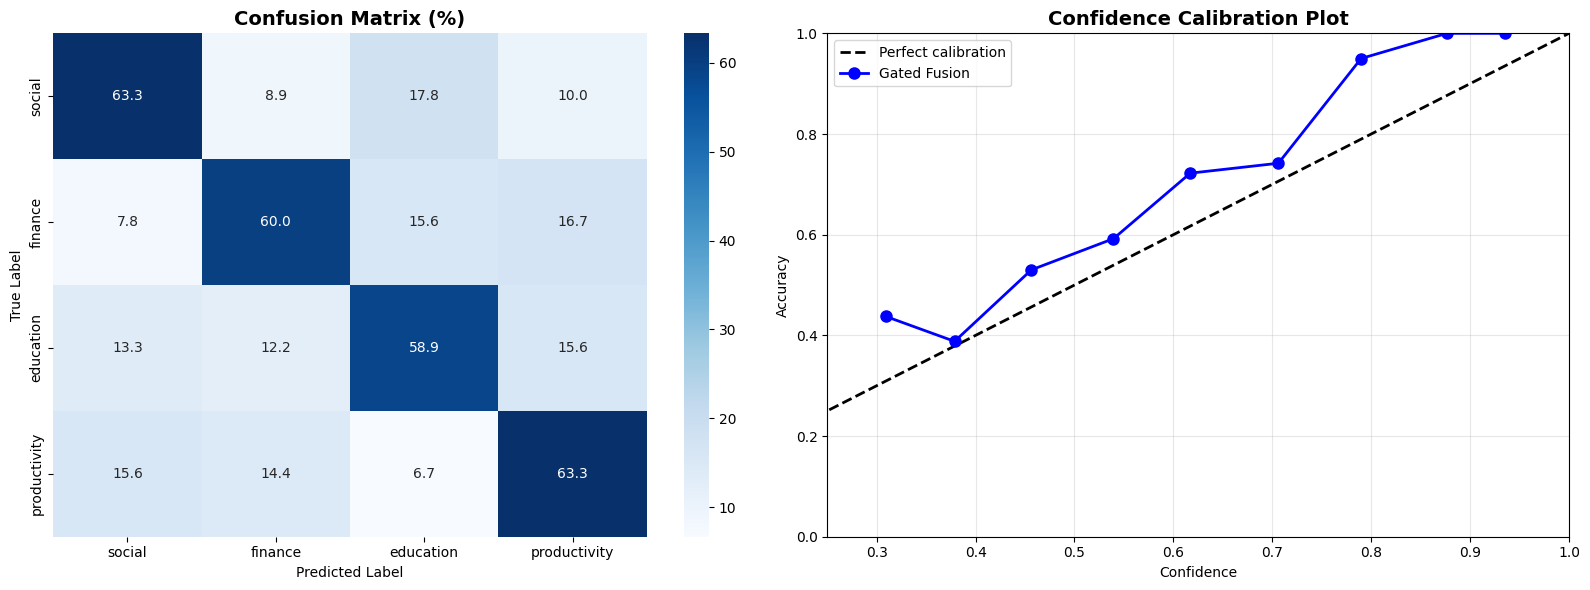

✅ Plots saved to Drive

✅ Evaluation complete — test_acc: 61.4%


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 19 — Full Test Evaluation
# Confusion matrix, per-class F1, calibration plot
# ═══════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load best checkpoint — try local first, then Drive
gated_model = GatedFusionModel().to(device)
loaded      = False

for ckpt_path in [LOCAL_CKPT, CKPT_DIR / 'gated-fusion_best.pt']:
    try:
        ckpt = torch.load(ckpt_path, map_location=device,
                          weights_only=False)
        gated_model.load_state_dict(ckpt['model_state'])
        gated_model.eval()
        print(f"✅ Loaded: {ckpt_path.name} — val_acc: {ckpt['val_acc']:.1f}%")
        loaded = True
        break
    except Exception as e:
        print(f"⚠️  {ckpt_path.name}: {e}")

if not loaded:
    print("❌ No valid checkpoint found — please retrain Cell 18")
else:
    # ── Inference on test set ─────────────────────
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels, tokens, ocr_flags in tqdm(
                test_loader, desc="Testing"):
            imgs   = imgs.to(device)
            labels = labels.to(device)
            tokens = {k: v.to(device) for k,v in tokens.items()}
            logits = gated_model(imgs, labels, tokens, ocr_flags)
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    test_acc   = (all_preds == all_labels).mean() * 100

    print(f"\n📊 Test Accuracy: {test_acc:.1f}%")
    print("\n📊 Per-class Results:")
    print(classification_report(
        all_labels, all_preds,
        target_names=CLASSES, digits=3))

    # ── Confusion Matrix ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    cm     = confusion_matrix(all_labels, all_preds)
    cm_pct = cm.astype(float) / \
             cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f',
                xticklabels=CLASSES, yticklabels=CLASSES,
                cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix (%)',
                       fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # ── Calibration Plot ──────────────────────────
    max_probs = all_probs.max(axis=1)
    correct   = (all_preds == all_labels).astype(int)
    bins      = np.linspace(0.25, 1.0, 10)
    bin_acc, bin_conf = [], []

    for i in range(len(bins)-1):
        mask = (max_probs >= bins[i]) & (max_probs < bins[i+1])
        if mask.sum() > 5:
            bin_acc.append(correct[mask].mean())
            bin_conf.append(max_probs[mask].mean())

    axes[1].plot([0,1], [0,1], 'k--', lw=2,
                 label='Perfect calibration')
    axes[1].plot(bin_conf, bin_acc, 'bo-', lw=2,
                 ms=8, label='Gated Fusion')
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Confidence Calibration Plot',
                       fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([0.25, 1.0])
    axes[1].set_ylim([0.0,  1.0])

    plt.tight_layout()
    plt.savefig(BASE / 'evaluation_plots.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print("✅ Plots saved to Drive")

    # ── Save results ──────────────────────────────
    with open(ABLATION) as f:
        ablation = json.load(f)
    ablation['gated_fusion']['test_acc'] = round(test_acc, 2)
    with open(ABLATION, 'w') as f:
        json.dump(ablation, f, indent=2)

    print(f"\n✅ Evaluation complete — test_acc: {test_acc:.1f}%")

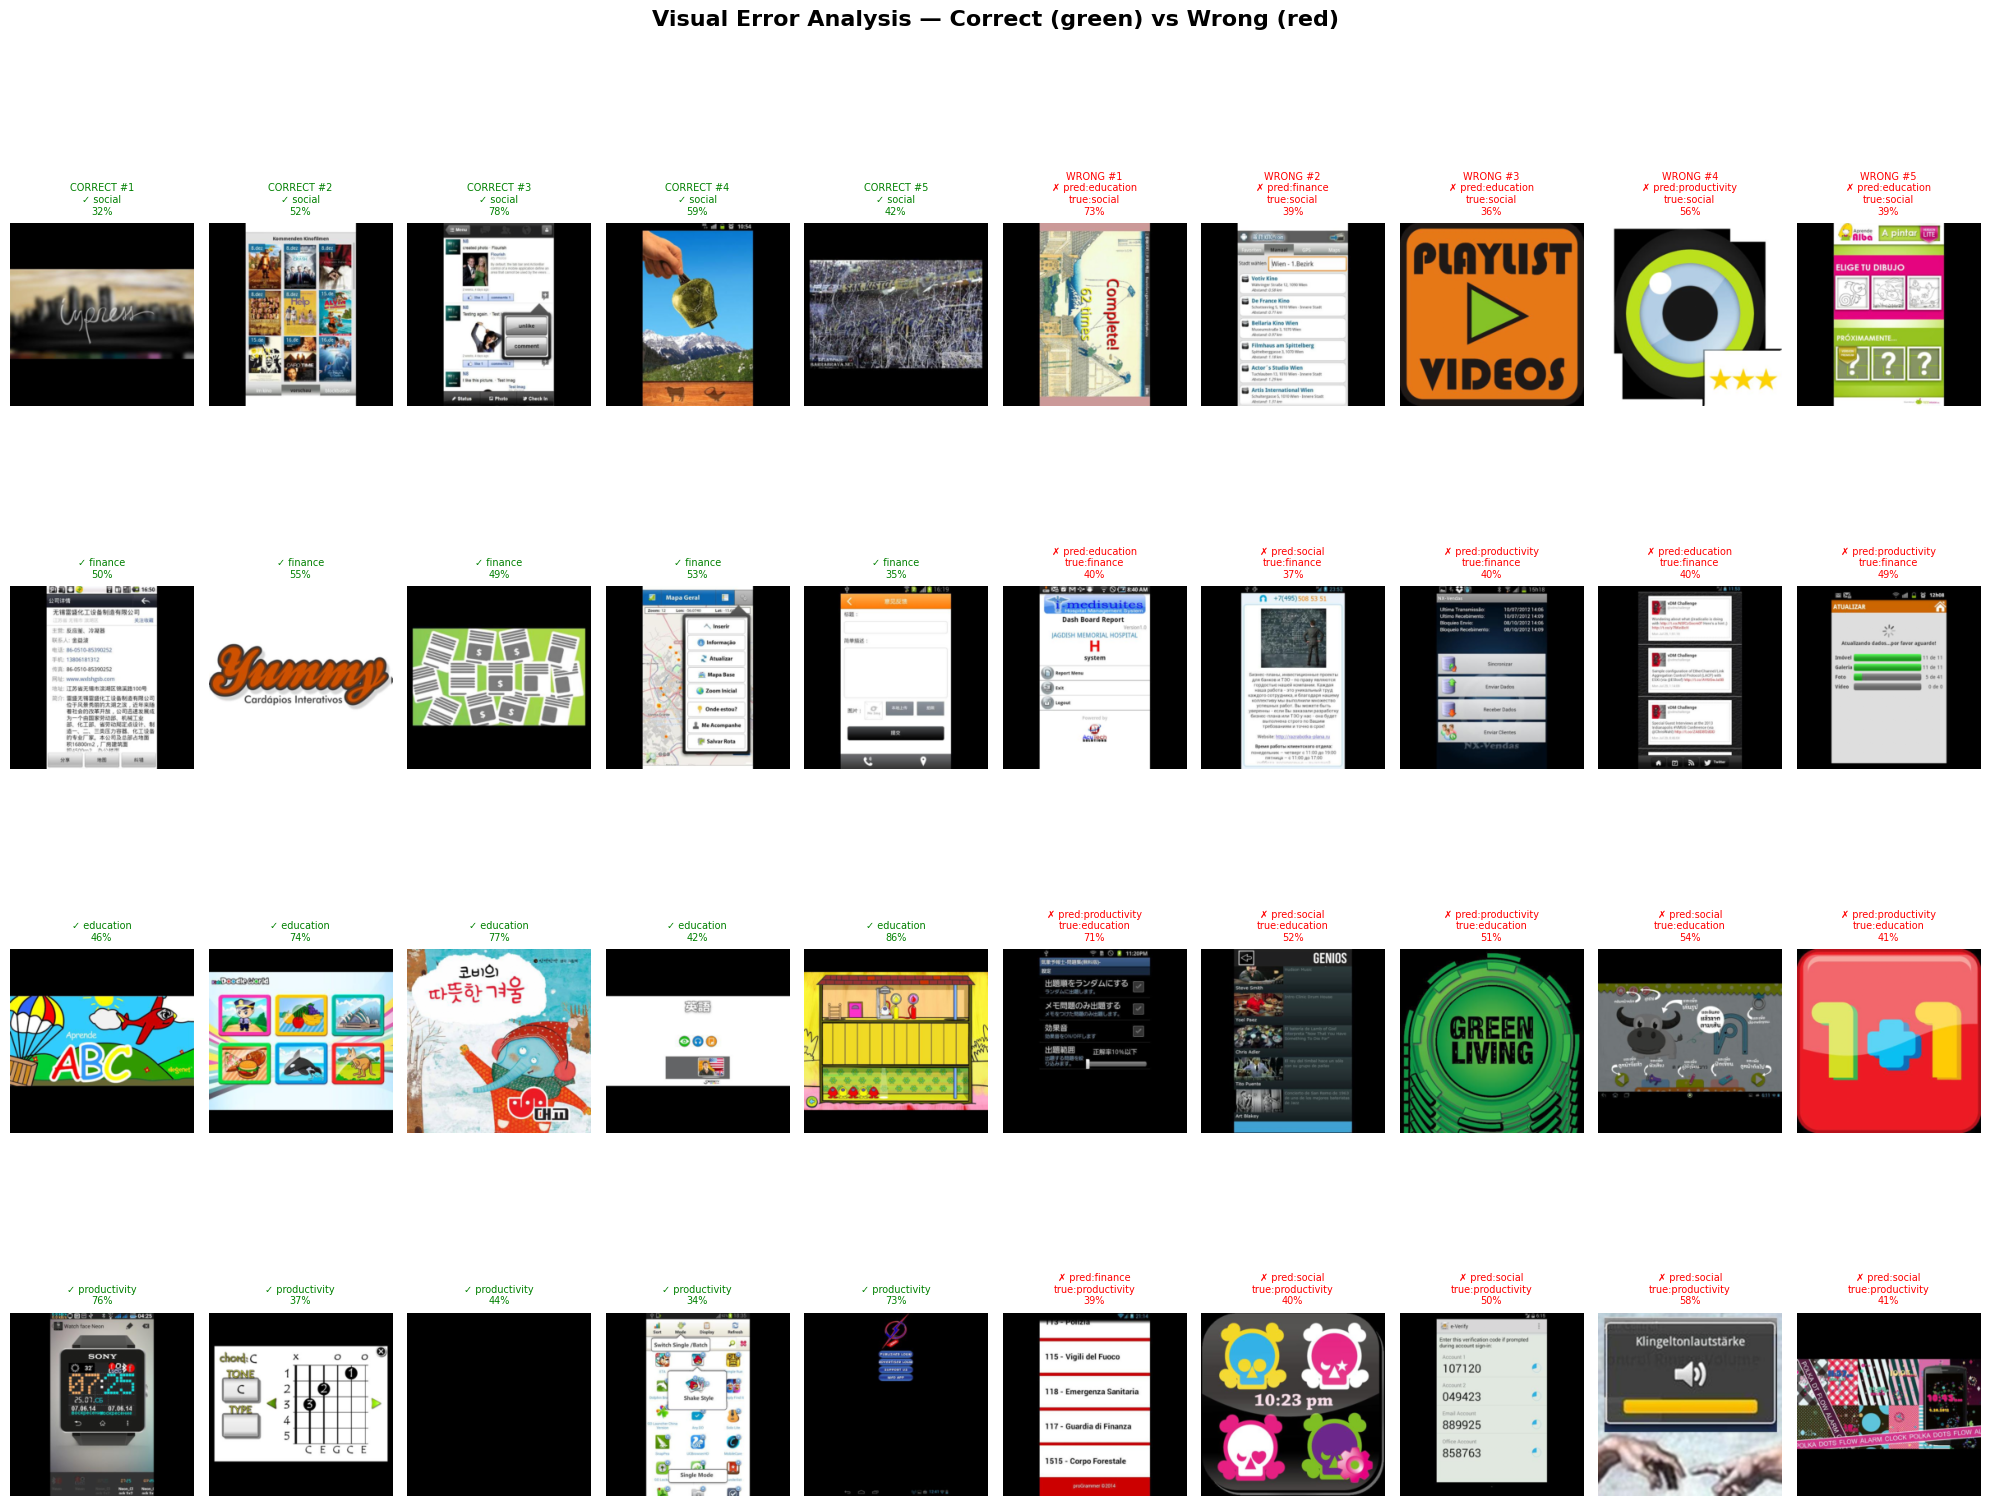

✅ Error analysis saved to Drive

📊 Wrong prediction analysis:
   (showing OCR text for misclassified samples)

  SOCIAL — 33 wrong out of 90
    → predicted as education: 16 times
    → predicted as productivity: 9 times
    → predicted as finance: 8 times

  FINANCE — 36 wrong out of 90
    → predicted as productivity: 15 times
    → predicted as education: 14 times
    → predicted as social: 7 times

  EDUCATION — 37 wrong out of 90
    → predicted as productivity: 14 times
    → predicted as social: 12 times
    → predicted as finance: 11 times

  PRODUCTIVITY — 33 wrong out of 90
    → predicted as social: 14 times
    → predicted as finance: 13 times
    → predicted as education: 6 times

✅ Error analysis complete


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 20 — Visual Error Analysis
# Shows 5 correct + 5 wrong predictions per class
# With OCR text and confidence scores
# ═══════════════════════════════════════════════════

fig_rows = len(CLASSES)
fig, axes = plt.subplots(fig_rows, 10, figsize=(20, 4*fig_rows))
fig.suptitle('Visual Error Analysis — Correct (green) vs Wrong (red)',
             fontsize=16, fontweight='bold', y=1.02)

# Collect all test samples with predictions
gated_model.eval()
sample_results = []

with torch.no_grad():
    for imgs, labels, tokens, ocr_flags in test_loader:
        imgs_raw = imgs.clone()
        imgs     = imgs.to(device)
        labels   = labels.to(device)
        tokens   = {k: v.to(device) for k,v in tokens.items()}
        logits   = gated_model(imgs, labels, tokens, ocr_flags)
        probs    = torch.softmax(logits, dim=1)
        preds    = logits.argmax(dim=1)
        confs    = probs.max(dim=1).values

        for i in range(len(labels)):
            sample_results.append({
                'img':        imgs_raw[i],
                'true':       labels[i].item(),
                'pred':       preds[i].item(),
                'conf':       confs[i].item(),
                'correct':    (preds[i] == labels[i]).item()
            })

# For each class show 5 correct + 5 wrong
for row, cls in enumerate(CLASSES):
    cls_idx   = CLASS2IDX[cls]
    cls_samples = [s for s in sample_results if s['true'] == cls_idx]

    correct_samples = [s for s in cls_samples if s['correct']][:5]
    wrong_samples   = [s for s in cls_samples if not s['correct']][:5]

    # Denormalize image for display
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073])
    std  = torch.tensor([0.26862954, 0.26130258, 0.27577711])

    def denorm(t):
        t = t.clone()
        for c in range(3):
            t[c] = t[c] * std[c] + mean[c]
        return t.permute(1,2,0).clamp(0,1).numpy()

    for col, s in enumerate(correct_samples):
        ax = axes[row][col]
        ax.imshow(denorm(s['img']))
        ax.set_title(f"✓ {CLASSES[s['pred']]}\n{s['conf']:.0%}",
                     color='green', fontsize=7)
        ax.axis('off')

    for col, s in enumerate(wrong_samples):
        ax = axes[row][col+5]
        ax.imshow(denorm(s['img']))
        ax.set_title(
            f"✗ pred:{CLASSES[s['pred']]}\ntrue:{CLASSES[s['true']]}\n{s['conf']:.0%}",
            color='red', fontsize=7)
        ax.axis('off')

    # Row label
    axes[row][0].set_ylabel(cls.upper(), fontsize=10,
                             fontweight='bold', rotation=0,
                             labelpad=60)

# Column headers
for col in range(5):
    axes[0][col].set_title(
        f"CORRECT #{col+1}\n" + axes[0][col].get_title(),
        color='green', fontsize=7)
for col in range(5):
    axes[0][col+5].set_title(
        f"WRONG #{col+1}\n" + axes[0][col+5].get_title(),
        color='red', fontsize=7)

plt.tight_layout()
plt.savefig(BASE / 'error_analysis.png', dpi=120,
            bbox_inches='tight')
plt.show()
print("✅ Error analysis saved to Drive")

# ── Text analysis of wrong predictions ───────────
print("\n📊 Wrong prediction analysis:")
print("   (showing OCR text for misclassified samples)\n")

for cls in CLASSES:
    cls_idx  = CLASS2IDX[cls]
    wrong    = [s for s in sample_results
                if s['true'] == cls_idx and not s['correct']]
    print(f"  {cls.upper()} — {len(wrong)} wrong out of 90")
    # Show which classes it was confused with
    confused = {}
    for s in wrong:
        pred_cls = CLASSES[s['pred']]
        confused[pred_cls] = confused.get(pred_cls, 0) + 1
    for pred_cls, count in sorted(confused.items(),
                                   key=lambda x: -x[1]):
        print(f"    → predicted as {pred_cls}: {count} times")
    print()

print("✅ Error analysis complete")

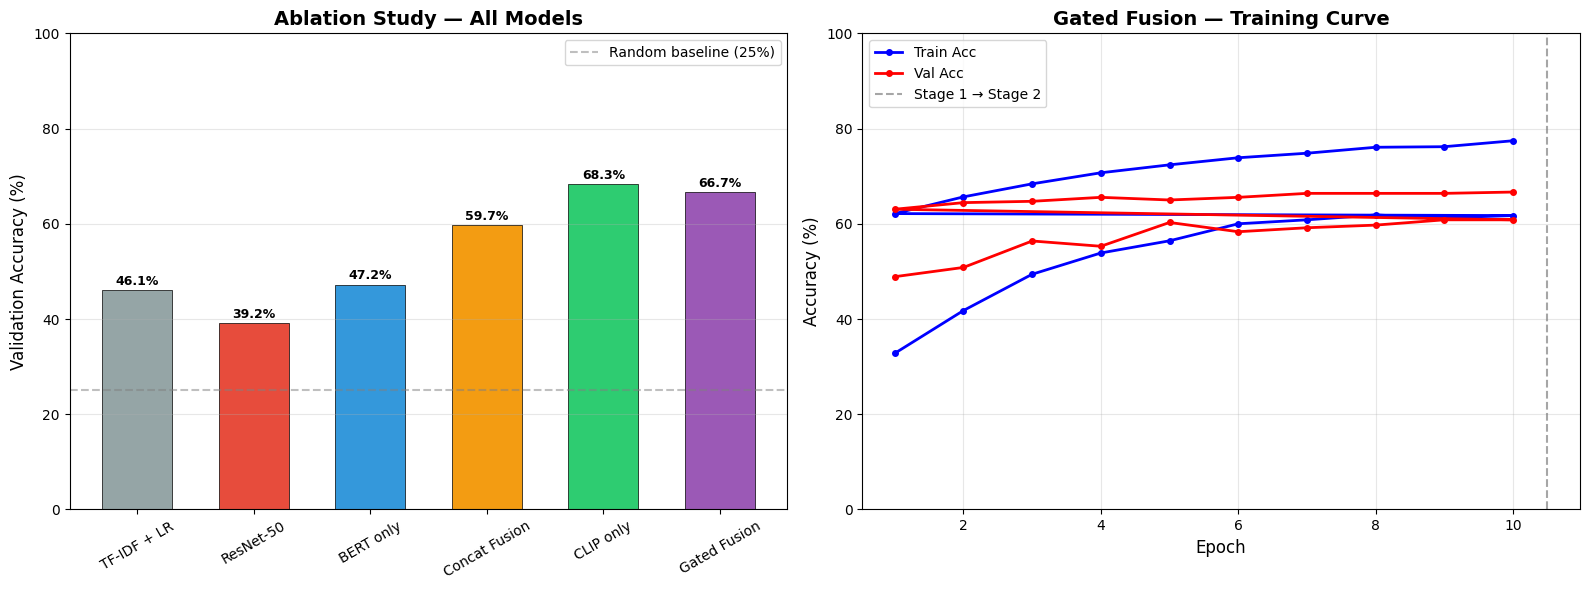

✅ Ablation plot saved to Drive

FINAL ABLATION SUMMARY
Model                   Val Acc  Test Acc
-------------------------------------------------------
TF-IDF + LR             46.11 %   43.06 %
ResNet-50               39.17 %       - %
BERT only               47.22 %       - %
Concat Fusion           59.72 %       - %
CLIP only               68.33 %       - %
Gated Fusion            66.67 %   61.39 % ← best

Random baseline (4 classes) : 25.0%
Best model improvement over
  random baseline : +41.7%
  TF-IDF baseline : +20.6%
  ResNet baseline : +27.5%


In [ ]:
# ═══════════════════════════════════════════════════
# CELL 21 — Ablation Results Table + Training Curves
# Final summary visualization for report
# ═══════════════════════════════════════════════════

with open(ABLATION) as f:
    ablation = json.load(f)

# ── Figure 1: Ablation Bar Chart ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = {
    'tfidf_lr':      'TF-IDF + LR',
    'resnet50':      'ResNet-50',
    'bert_only':     'BERT only',
    'concat_fusion': 'Concat Fusion',
    'clip_only':     'CLIP only',
    'gated_fusion':  'Gated Fusion'
}
colors = ['#95a5a6', '#e74c3c', '#3498db',
          '#f39c12', '#2ecc71', '#9b59b6']

names   = [model_names[k] for k in model_names]
val_accs = [ablation[k]['val_acc'] for k in model_names]

bars = axes[0].bar(names, val_accs, color=colors, width=0.6,
                   edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[0].set_title('Ablation Study — All Models',
                   fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=25, color='gray', linestyle='--',
                alpha=0.5, label='Random baseline (25%)')
axes[0].legend()

# Add value labels on bars
for bar, acc in zip(bars, val_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{acc:.1f}%', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# ── Figure 2: Gated Fusion Training Curve ─────────
history = ablation['gated_fusion'].get('history', [])

if history:
    epochs     = [h['epoch'] for h in history]
    train_accs = [h['train_acc'] for h in history]
    val_accs_h = [h['val_acc'] for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss   = [h['val_loss'] for h in history]

    ax2 = axes[1]
    ax2.plot(epochs, train_accs, 'b-o', ms=4,
             label='Train Acc', linewidth=2)
    ax2.plot(epochs, val_accs_h, 'r-o', ms=4,
             label='Val Acc', linewidth=2)
    ax2.axvline(x=10.5, color='gray', linestyle='--',
                alpha=0.7, label='Stage 1 → Stage 2')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title('Gated Fusion — Training Curve',
                   fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 100])

plt.tight_layout()
plt.savefig(BASE / 'ablation_results.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Ablation plot saved to Drive")

# ── Print final summary table ─────────────────────
print("\n" + "="*55)
print("FINAL ABLATION SUMMARY")
print("="*55)
print(f"{'Model':<22} {'Val Acc':>8} {'Test Acc':>9}")
print("-"*55)
for k, name in model_names.items():
    val  = ablation[k].get('val_acc', '-')
    test = ablation[k].get('test_acc', '-')
    marker = ' ← best' if k == 'gated_fusion' else ''
    print(f"{name:<22} {str(val)+' %':>8} {str(test)+' %':>9}{marker}")
print("="*55)
print(f"\nRandom baseline (4 classes) : 25.0%")
print(f"Best model improvement over")
print(f"  random baseline : +{66.7-25:.1f}%")
print(f"  TF-IDF baseline : +{66.7-46.1:.1f}%")
print(f"  ResNet baseline : +{66.7-39.2:.1f}%")

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ Loaded: clip-only_best.pt — val_acc: 68.3%


Evaluating CLIP-only: 100%|██████████| 12/12 [00:03<00:00,  3.15it/s]



📊 CLIP-only Test Accuracy: 61.9%

📊 Per-class Results:
              precision    recall  f1-score   support

      social      0.683     0.622     0.651        90
     finance      0.573     0.611     0.591        90
   education      0.667     0.622     0.644        90
productivity      0.571     0.622     0.596        90

    accuracy                          0.619       360
   macro avg      0.623     0.619     0.620       360
weighted avg      0.623     0.619     0.620       360



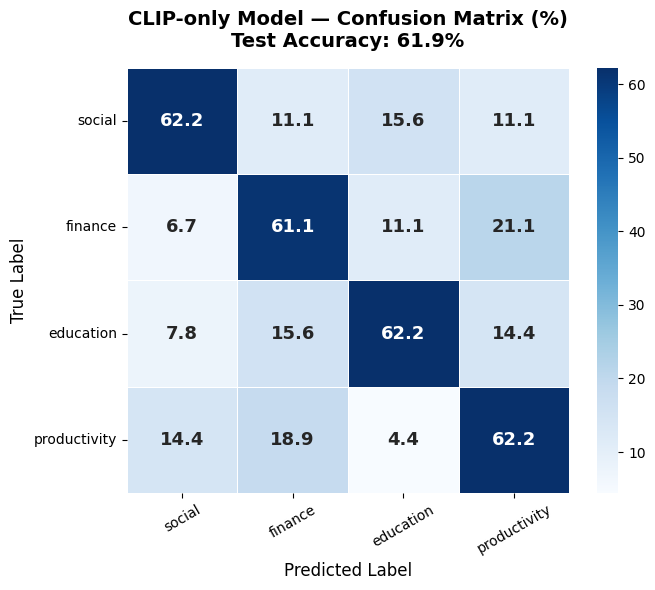


✅ Saved to Drive: /content/drive/MyDrive/screenshot_organizer_v2/clip_only_confusion_matrix.png


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Confusion Matrix for CLIP-only model
# ═══════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ── Load CLIP-only checkpoint ──────────────────────
clip_ckpt_path = CKPT_DIR / 'clip-only_best.pt'

clip_model = CLIPOnlyModel().to(device)
loaded = False

for ckpt_path in [CKPT_DIR / 'clip-only_best.pt',
                  CKPT_DIR / 'clip_only_best.pt',
                  CKPT_DIR / 'clip-only_best.pt']:
    if ckpt_path.exists():
        try:
            ckpt = torch.load(ckpt_path,
                              map_location=device,
                              weights_only=False)
            clip_model.load_state_dict(ckpt['model_state'])
            clip_model.eval()
            print(f"✅ Loaded: {ckpt_path.name}"
                  f" — val_acc: {ckpt['val_acc']:.1f}%")
            loaded = True
            break
        except Exception as e:
            print(f"⚠️  {ckpt_path.name}: {e}")

if not loaded:
    raise RuntimeError(
        "❌ CLIP checkpoint not found.\n"
        "   Available checkpoints:")
    for f in CKPT_DIR.glob('*.pt'):
        print(f"   {f.name}")

# ── Run inference on test set ──────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels, tokens, ocr_flags in tqdm(
            test_loader, desc="Evaluating CLIP-only"):
        imgs   = imgs.to(device)
        labels = labels.to(device)
        tokens = {k: v.to(device) for k, v in tokens.items()}

        logits = clip_model(imgs, labels, tokens, ocr_flags)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean() * 100

print(f"\n📊 CLIP-only Test Accuracy: {test_acc:.1f}%")
print("\n📊 Per-class Results:")
print(classification_report(
    all_labels, all_preds,
    target_names=CLASSES, digits=3))

# ── Plot Confusion Matrix ──────────────────────────
cm     = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / \
         cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm_pct,
    annot      = True,
    fmt        = '.1f',
    xticklabels= CLASSES,
    yticklabels= CLASSES,
    cmap       = 'Blues',
    ax         = ax,
    linewidths = 0.5,
    annot_kws  = {'size': 13, 'weight': 'bold'}
)

ax.set_title(
    f'CLIP-only Model — Confusion Matrix (%)\n'
    f'Test Accuracy: {test_acc:.1f}%',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_ylabel('True Label',     fontsize=12)
ax.set_xlabel('Predicted Label',fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()

# Save to Drive
save_path = BASE / 'clip_only_confusion_matrix.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved to Drive: {save_path}")

CLIP-only calibration: 100%|██████████| 12/12 [00:05<00:00,  2.06it/s]


📊 ECE: 0.0490  (lower = better calibrated)


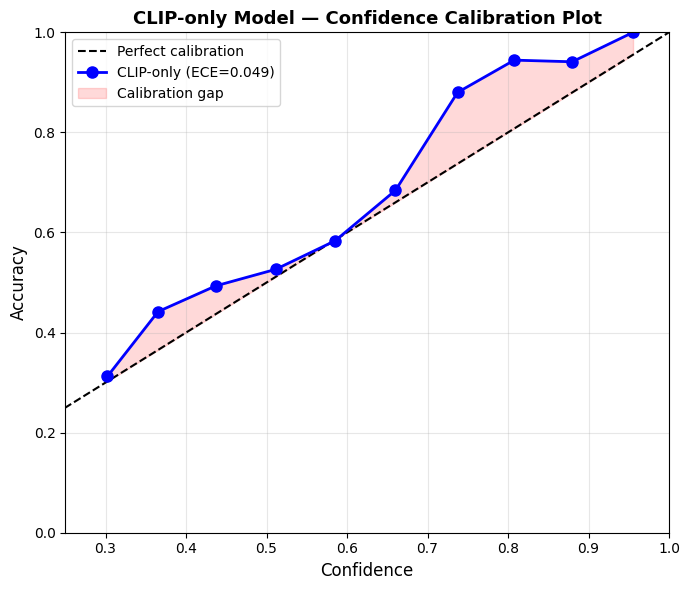

✅ Saved: /content/drive/MyDrive/screenshot_organizer_v2/clip_only_calibration.png


In [ ]:
# ═══════════════════════════════════════════════════
# CELL — Calibration Plot for CLIP-only model
# ═══════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

# ── Run inference to get probabilities ────────────
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels, tokens, ocr_flags in tqdm(
            test_loader, desc="CLIP-only calibration"):
        imgs   = imgs.to(device)
        labels = labels.to(device)
        tokens = {k: v.to(device) for k, v in tokens.items()}

        logits = clip_model(imgs, labels, tokens, ocr_flags)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Calibration calculation ────────────────────────
max_probs = all_probs.max(axis=1)
correct   = (all_preds == all_labels).astype(int)

bins     = np.linspace(0.25, 1.0, 11)
bin_acc  = []
bin_conf = []
bin_count= []

for i in range(len(bins) - 1):
    mask = (max_probs >= bins[i]) & (max_probs < bins[i+1])
    if mask.sum() > 3:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(max_probs[mask].mean())
        bin_count.append(mask.sum())

bin_acc  = np.array(bin_acc)
bin_conf = np.array(bin_conf)

# ECE score
weights = np.array(bin_count) / len(all_preds)
ece     = np.sum(weights * np.abs(bin_acc - bin_conf))
print(f"📊 ECE: {ece:.4f}  (lower = better calibrated)")

# ── Plot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 1], [0, 1], 'k--',
        linewidth=1.5, label='Perfect calibration')
ax.plot(bin_conf, bin_acc, 'bo-',
        linewidth=2, markersize=8,
        label=f'CLIP-only (ECE={ece:.3f})')
ax.fill_between(bin_conf, bin_acc, bin_conf,
                alpha=0.15, color='red',
                label='Calibration gap')

ax.set_xlabel('Confidence', fontsize=12)
ax.set_ylabel('Accuracy',   fontsize=12)
ax.set_title(
    'CLIP-only Model — Confidence Calibration Plot',
    fontsize=13, fontweight='bold')
ax.set_xlim([0.25, 1.0])
ax.set_ylim([0.0,  1.0])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

# ── Save ───────────────────────────────────────────
save_path = BASE / 'clip_only_calibration.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {save_path}")

In [ ]:
!pip install -q gradio==3.50.2 gradio_client==0.6.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.2/299.2 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
dataproc-spark-connect 1.0.2 requires websockets>=14.0, but you have websockets 11.0.3 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-genai 1.67.0 requires websockets<17.0,>=13.0.0, but you have webs

In [ ]:
# ═══════════════════════════════════════════════════
# CELL — GUI using ipywidgets (no Gradio, no server)
# Runs natively inside Colab — no external URL needed
# ═══════════════════════════════════════════════════

import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io, re, torch, threading
import pytesseract

# ── Constants ──────────────────────────────────────
CLASSES     = ['social', 'finance', 'education', 'productivity']
CLASS_EMOJI = {
    'social'      : '💬 Social',
    'finance'     : '💰 Finance',
    'education'   : '📚 Education',
    'productivity': '📋 Productivity'
}

# ── Safe OCR ───────────────────────────────────────
def safe_ocr(image, timeout=6):
    result = {'text': 'no text detected', 'quality': 0}
    def _run():
        try:
            img = image.copy()
            if max(img.size) > 800:
                img.thumbnail((800, 800), Image.LANCZOS)
            raw   = pytesseract.image_to_string(img)
            raw   = re.sub(r'\s+', ' ', raw).strip()
            words = [w for w in raw.split()
                     if len(w) > 2 and w.isalnum()]
            if len(words) >= 2:
                result['text']    = raw
                result['quality'] = 1
        except Exception:
            pass
    t = threading.Thread(target=_run, daemon=True)
    t.start()
    t.join(timeout=timeout)
    return result['text'], result['quality']

# ── Inference ──────────────────────────────────────
def run_inference(image):
    ocr_text, quality = safe_ocr(image, timeout=6)

    img_t  = CLIP_TRANSFORM(image).unsqueeze(0).to(device)
    tokens = bert_tokenizer(
        [ocr_text], padding=True,
        truncation=True, max_length=128,
        return_tensors='pt'
    )
    tokens   = {k: v.to(device) for k, v in tokens.items()}
    ocr_flag = torch.tensor([quality],
                             dtype=torch.float).to(device)

    with torch.no_grad():
        logits = gated_model(img_t, None, tokens, ocr_flag)
        probs  = torch.softmax(logits, dim=1)[0]
        pred   = probs.argmax().item()
        conf   = probs[pred].item()

    return probs, pred, conf, ocr_text

# ── Build UI ───────────────────────────────────────
title = widgets.HTML(
    '<h2 style="text-align:center">📱 Screenshot Organizer'
    ' — Multimodal Classifier</h2>'
    '<p style="text-align:center">Upload a screenshot → '
    'classify as Social / Finance / Education / Productivity</p>'
)

upload_btn = widgets.FileUpload(
    accept='.png,.jpg,.jpeg',
    multiple=False,
    description='📤 Upload',
    layout=widgets.Layout(width='200px')
)

submit_btn = widgets.Button(
    description  = '🔍 Classify',
    button_style = 'primary',
    layout       = widgets.Layout(width='150px', height='40px')
)

clear_btn = widgets.Button(
    description  = '🗑️ Clear',
    button_style = 'warning',
    layout       = widgets.Layout(width='150px', height='40px')
)

img_display  = widgets.Output()
result_box   = widgets.Textarea(
    value       = '',
    placeholder = 'Result will appear here...',
    layout      = widgets.Layout(width='100%', height='250px')
)
status_label = widgets.Label(value='')

# ── Button callbacks ───────────────────────────────
def on_submit(b):
    if not upload_btn.value:
        status_label.value = '⚠️ Please upload an image first!'
        return

    status_label.value  = '⏳ Processing...'
    result_box.value    = ''
    submit_btn.disabled = True

    try:
        # Read uploaded file
        uploaded_file = list(upload_btn.value.values())[0]
        img_bytes = uploaded_file['content']
        image     = Image.open(io.BytesIO(img_bytes)).convert('RGB')

        # Show preview
        with img_display:
            clear_output(wait=True)
            display(image.resize((200, 200)))

        # Run inference
        probs, pred, conf, ocr_text = run_inference(image)
        pred_cls = CLASSES[pred]

        # Format result
        out  = f"{'='*45}\n"
        out += f"  PREDICTION : {CLASS_EMOJI[pred_cls]}\n"
        out += f"  CONFIDENCE : {conf:.1%}\n"
        out += f"{'='*45}\n\n"
        out += "All Probabilities:\n"
        for i, cls in enumerate(CLASSES):
            bar    = '█' * int(probs[i].item() * 25)
            marker = '  ← predicted' if i == pred else ''
            out   += (f"  {CLASS_EMOJI[cls]:<22}"
                      f"{probs[i].item():.1%}  {bar}{marker}\n")
        out += f"\n{'─'*45}\n"
        out += f"📝 OCR: {ocr_text[:150]}"

        result_box.value   = out
        status_label.value = f'✅ Done!'

    except Exception as e:
        result_box.value   = f'❌ Error: {str(e)}'
        status_label.value = '❌ Failed'

    submit_btn.disabled = False

def on_clear(b):
    result_box.value   = ''
    status_label.value = ''
    with img_display:
        clear_output()

submit_btn.on_click(on_submit)
clear_btn.on_click(on_clear)

# ── Layout and display ─────────────────────────────
buttons = widgets.HBox([submit_btn, clear_btn],
    layout=widgets.Layout(
        justify_content='center', margin='10px'))

ui = widgets.VBox([
    title,
    widgets.HBox([upload_btn],
        layout=widgets.Layout(justify_content='center')),
    buttons,
    status_label,
    img_display,
    widgets.HTML('<b>🔍 Classification Result:</b>'),
    result_box
], layout=widgets.Layout(
    border='1px solid #444',
    padding='20px',
    width='700px',
    margin='auto'
))

display(ui)
print("✅ GUI ready — upload an image and click Classify!")

✅ GUI ready — upload an image and click Classify!
